In [1]:
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file
from histpy import Histogram

from scoords import SpacecraftFrame

from astropy.time import Time
import astropy.units as u

SED_KEV_TO_ERG = u.keV.to(u.erg)
KEV_TO_MEV = u.keV.to(u.MeV)
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from threeML import *
from threeML.io.package_data import get_path_of_data_file
from threeML.io.logging import silence_console_log
from astromodels import Parameter
from threeML.minimizer.minimization import CannotComputeCovariance

from jupyterthemes import jtplot
jtplot.style(context="talk", fscale=1, ticks=True, grid=False)
set_threeML_style()
silence_warnings()

from scipy.integrate import quad

import matplotlib.ticker as mticker

from pathlib import Path

import os

%matplotlib inline

17:00:35 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=512858;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=392575;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=140229;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=326546;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=389615;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=844971;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

17:00:36 INFO      Starting 3ML!                                                                     ]8;id=990207;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=784536;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=41734;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=584763;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=588259;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=723955;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

17:00:38 WARNING   No fermitools installed                                              ]8;id=475557;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=998553;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=745837;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=572559;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=938674;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=564310;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=586087;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=301600;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

In [2]:
# Simulation paths are defined with the histogram inputs below.

In [3]:
from astropy import units as u
from astropy.coordinates import SkyCoord
from cosipy.event_selection import GoodTimeInterval
from agn_cosi_fit_utils import draw_energy_hist_mev, open_spacecraft_history, scale_spacecraft_livetime

orientation_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
source_coord = SkyCoord(l=155.077, b=75.063, frame="galactic", unit="deg")
fov_cut = 60 * u.deg

full_sc_orientation = open_spacecraft_history(orientation_path)
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    full_sc_orientation,
    fov_cut,
    earth_occ=False,
)
sc_orientation = full_sc_orientation.apply_gti(source_gti)

print(f"NGC 4151 FOV cut: {fov_cut.to_value(u.deg):.0f} deg")
print(f"Selected livetime: {sc_orientation.cumulative_livetime().to_value(u.s):,.1f} s")

NGC 4151 FOV cut: 60 deg
Selected livetime: 980,415.0 s


In [4]:
dr = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"

In [5]:
multiplier_4151 = 8

exposure_4151 = multiplier_4151 * 3

# Scale count histograms and response livetime together; keep source flux intrinsic.
sc_orientation = scale_spacecraft_livetime(sc_orientation, multiplier_4151)

# Spectral Fitting

In [6]:
import json

sensitivity_dir = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble")
ec200_manifest_file = sensitivity_dir / "Case2_ec200" / f"NGC4151_ec200_NTH_threshold_median_realization_{exposure_4151}months.json"
if not ec200_manifest_file.exists():
    raise FileNotFoundError(f"Run the Case2_ec200 sensitivity notebook first: {ec200_manifest_file}")
with ec200_manifest_file.open() as stream:
    ec200_manifest = json.load(stream)
NGC4151_ec200 = Histogram.open(ec200_manifest["source_expectation_file"])
NGC4151_ec200_bkg = Histogram.open(ec200_manifest["median_data_file"])

bkg = Histogram.open(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files/Background/"
    "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
    "NGC4151_60deg_fov_cut.hdf5"
) * multiplier_4151

# Collapse the background time axis.
bkg = bkg.project("Em", "Phi", "PsiChi")

# Match metadata, following the source-injector branch workflow.
NGC4151_ec200.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
NGC4151_ec200 = NGC4151_ec200.to(
    unit=bkg.unit,
    update=False,
)

NGC4151_ec200_bkg.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
NGC4151_ec200_bkg = NGC4151_ec200_bkg.to(unit=bkg.unit, update=False)
ec1000_manifest_file = sensitivity_dir / "Case2_ec1000" / f"NGC4151_ec1000_NTH_threshold_median_realization_{exposure_4151}months.json"
if not ec1000_manifest_file.exists():
    raise FileNotFoundError(f"Run the Case2_ec1000 sensitivity notebook first: {ec1000_manifest_file}")
with ec1000_manifest_file.open() as stream:
    ec1000_manifest = json.load(stream)
NGC4151_ec1000 = Histogram.open(ec1000_manifest["source_expectation_file"])
NGC4151_ec1000_bkg = Histogram.open(ec1000_manifest["median_data_file"])

# Match metadata, following the source-injector branch workflow.
NGC4151_ec1000.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
NGC4151_ec1000 = NGC4151_ec1000.to(
    unit=bkg.unit,
    update=False,
)

NGC4151_ec1000_bkg.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
NGC4151_ec1000_bkg = NGC4151_ec1000_bkg.to(unit=bkg.unit, update=False)

norm_nt_ec200 = ec200_manifest["grid_threshold_norm_nt"]  # 0.17
norm_nt_ec1000 = ec1000_manifest["grid_threshold_norm_nt"]  # 0.12

# Source Model Plots

## Cutoff Power Law (Thermal)

#### NGC 4151 (200 keV)

In [7]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

#### NGC 4151 (1000 keV)

In [8]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.75

spectrum_inj_ec1000 = Cutoff_powerlaw()

spectrum_inj_ec1000.K.value = K_inj.value
spectrum_inj_ec1000.piv.value = piv_inj.value
spectrum_inj_ec1000.xc.value = xc_inj.value
spectrum_inj_ec1000.index.value = index_inj

spectrum_inj_ec1000.K.unit = K_inj.unit
spectrum_inj_ec1000.piv.unit = piv_inj.unit
spectrum_inj_ec1000.xc.unit = xc_inj.unit

# Power law tail (Non-thermal)

#### NGC 4151 (200 keV)

In [9]:
# K_inj = 0.1*spectrum_inj_ec200.evaluate_at(1000) / u.cm / u.cm / u.s / u.keV
# piv_inj = 1000. * u.keV

def cutoff_powerlaw_k_at_pivot(shape, pivot_value):
    return float(shape.K.value * (pivot_value / shape.piv.value) ** shape.index.value)

K_inj = norm_nt_ec200*spectrum_inj_ec200.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -2.8

spectrum_inj_ec200_PL = Powerlaw()

spectrum_inj_ec200_PL.K.value = K_inj.value
spectrum_inj_ec200_PL.piv.value = piv_inj.value
spectrum_inj_ec200_PL.index.value = index_inj

spectrum_inj_ec200_PL.K.unit = K_inj.unit
spectrum_inj_ec200_PL.piv.unit = piv_inj.unit

spectrum_inj_ec200_total = spectrum_inj_ec200 + spectrum_inj_ec200_PL

print("K_inj: ", K_inj)
print(spectrum_inj_ec200.evaluate_at(200))
print(spectrum_inj_ec200_PL.evaluate_at(200))
print("="*40)
linking_ratio_ec200 = spectrum_inj_ec200_PL.K.value / cutoff_powerlaw_k_at_pivot(
    spectrum_inj_ec200,
    spectrum_inj_ec200_PL.piv.value,
)
print("Linking K ratio", linking_ratio_ec200)
print("Flux ratio at 200 keV", spectrum_inj_ec200_PL.evaluate_at(200)/spectrum_inj_ec200.evaluate_at(200))
print("="*40)
flux_th, _ = quad(spectrum_inj_ec200.evaluate_at, 100.0, 10000.0)
flux_nth, _ = quad(spectrum_inj_ec200_PL.evaluate_at, 100.0, 10000.0)
print("Non-thermal flux: ", flux_nth)
print("Total flux: ", flux_th + flux_nth)
print("Thermal - Non-thermal Flux Ratio: ", flux_th/flux_nth)
print("Non-thermal percentage: ", flux_nth/(flux_th + flux_nth))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_ec200 + spectrum_inj_ec200_PL).evaluate_at(E),
    100.0,
    10000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_ec200.K.value
    * (200.0 / spectrum_inj_ec200.piv.value) ** spectrum_inj_ec200.index.value
)

print(K_inj_at_fit_pivot)

K_inj:  8.819484597745403e-07 1 / (keV s cm2)
5.187932116320825e-06
8.819484597745404e-07
Linking K ratio 0.0625395049991452
Flux ratio at 200 keV 0.17000000000000004
Non-thermal flux:  0.0003411501647357597
Total flux:  0.0020841088490935033
Thermal - Non-thermal Flux Ratio:  5.109065932029564
Non-thermal percentage:  0.16369114544288088
energy_flux:  6.229442177910673e-10 erg / (s cm2)
energy_flux_err:  1.194684489924872e-19 erg / (s cm2)
1.4102261599073975e-05


#### NGC 4151 (1000 keV)

In [10]:
K_inj = norm_nt_ec1000*spectrum_inj_ec1000.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -2.8

spectrum_inj_ec1000_PL = Powerlaw()

spectrum_inj_ec1000_PL.K.value = K_inj.value
spectrum_inj_ec1000_PL.piv.value = piv_inj.value
spectrum_inj_ec1000_PL.index.value = index_inj

spectrum_inj_ec1000_PL.K.unit = K_inj.unit
spectrum_inj_ec1000_PL.piv.unit = piv_inj.unit

spectrum_inj_ec1000_total = spectrum_inj_ec1000 + spectrum_inj_ec1000_PL

print("K_inj: ", K_inj)
print(spectrum_inj_ec1000.evaluate_at(200))
print(spectrum_inj_ec1000_PL.evaluate_at(200))
print("="*40)
linking_ratio_ec1000 = spectrum_inj_ec1000_PL.K.value / cutoff_powerlaw_k_at_pivot(
    spectrum_inj_ec1000,
    spectrum_inj_ec1000_PL.piv.value,
)
print("Linking K ratio", linking_ratio_ec1000)
print("Flux ratio at 200 keV", spectrum_inj_ec1000_PL.evaluate_at(200)/spectrum_inj_ec1000.evaluate_at(200))
print("="*40)
flux_th, _ = quad(spectrum_inj_ec1000.evaluate_at, 100.0, 10000.0)
flux_nth, _ = quad(spectrum_inj_ec1000_PL.evaluate_at, 100.0, 10000.0)
print("Non-thermal flux: ", flux_nth)
print("Total flux: ", flux_th + flux_nth)
print("Thermal - Non-thermal Flux Ratio: ", flux_th/flux_nth)
print("Non-thermal percentage: ", flux_nth/(flux_th + flux_nth))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_ec1000 + spectrum_inj_ec1000_PL).evaluate_at(E),
    100.0,
    10000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_ec1000.K.value
    * (200.0 / spectrum_inj_ec1000.piv.value) ** spectrum_inj_ec1000.index.value
)

print(K_inj_at_fit_pivot)

K_inj:  1.3855146310935058e-06 1 / (keV s cm2)
1.1545955259112548e-05
1.3855146310935069e-06
Linking K ratio 0.09824769036935797
Flux ratio at 200 keV 0.12000000000000009
Non-thermal flux:  0.0005359366972103874
Total flux:  0.0046615691754160835
Thermal - Non-thermal Flux Ratio:  7.697984668114893
Non-thermal percentage:  0.11496916103632648
energy_flux:  2.1074644950885058e-09 erg / (s cm2)
energy_flux_err:  1.6873543626914734e-19 erg / (s cm2)
1.4102261599073975e-05


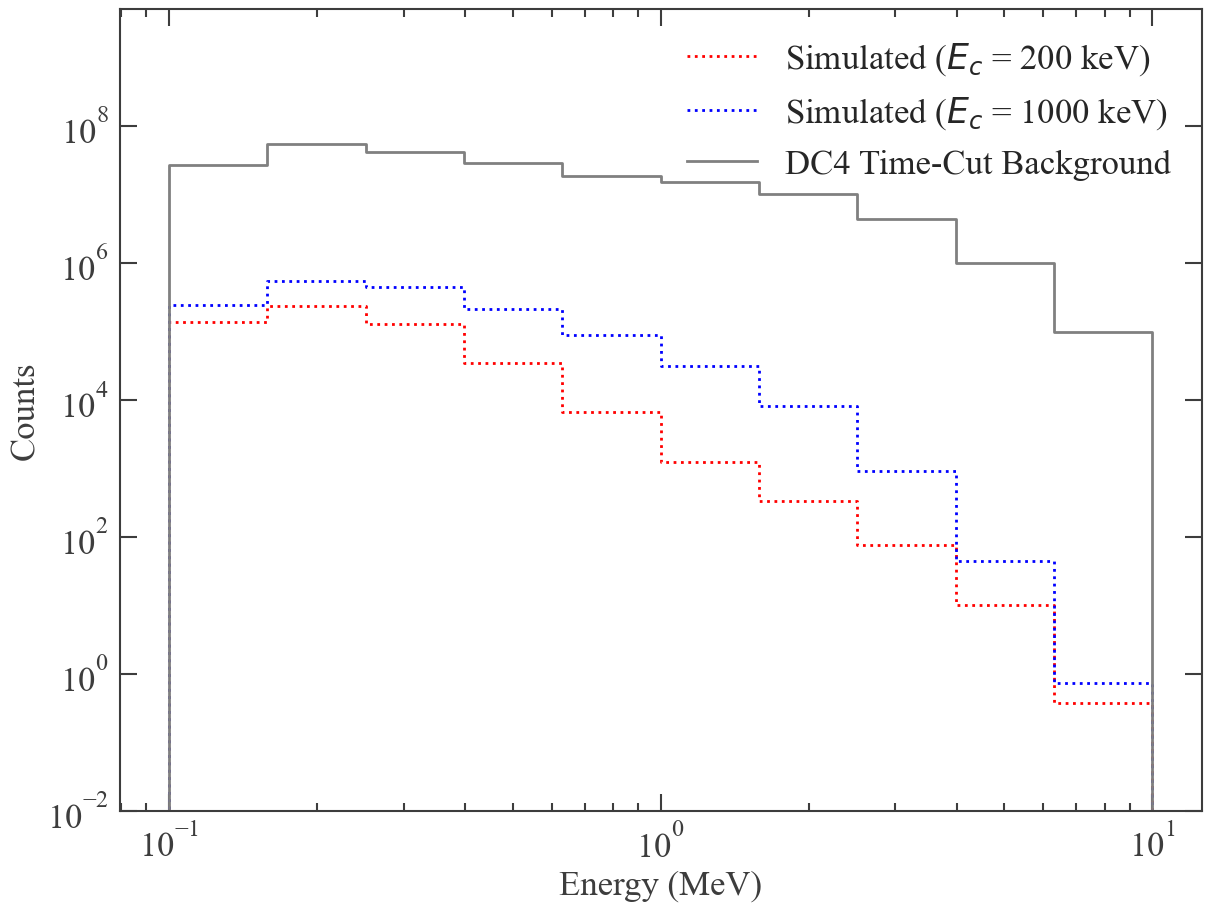

In [11]:
FONT_SIZE = 25
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

draw_energy_hist_mev(NGC4151_ec200, ax, label="Simulated ($E_c$ = 200 keV)", color="red", linestyle="dotted")
draw_energy_hist_mev(NGC4151_ec1000, ax, label="Simulated ($E_c$ = 1000 keV)", color="blue", linestyle="dotted")
draw_energy_hist_mev(bkg, ax, label="DC4 Time-Cut Background", color="grey")
# draw_energy_hist_mev(full_bkg, ax, label="DC4 Full Background", color="black", linestyle="dashdot")
# draw_energy_hist_mev(NGC4151_ec200_bkg, ax, label="NGC 4151 Model ($E_c$ = 200 keV) + Background", linestyle='dashdot', color="red")
# draw_energy_hist_mev(NGC4151_ec1000_bkg, ax, label="NGC 4151 Model ($E_c$ = 1000 keV) + Background", linestyle='dashdot', color="blue")

ax.set_yscale("log")
ax.set_xscale("log")

ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.set_ylim(1e-2, 5e9)

# ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1, 5]))
# ax.xaxis.set_major_formatter(
#     mticker.FixedFormatter(["0.2", "1.0", "5.0"])
# )

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.legend(fontsize=FONT_SIZE, loc='upper right', frameon=False)

# save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC4151_FullModel_Counts_200_1000_3Months.pdf"
# plt.savefig(save_path)

Define the path to the detector response

## Perform spectral fit

Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin

In [12]:
from agn_cosi_fit_utils import COSIPlugin, EnergyRangeCOSIPlugin, make_cosi_background_parameter

# Finite support for cells that are empty in the background histogram.
# This value is added to every cell before the background template is normalized.
BACKGROUND_PSEUDOCOUNT = None
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

bkg_par_ec1000 = Parameter("background_cosi_ec1000",                           # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSIPlugin("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec200_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 background_pseudocount = BACKGROUND_PSEUDOCOUNT,              # regularize empty background cells
                 earth_occ = True)                                             # Option to account for Earth occultation

cosi_ec1000 = COSIPlugin("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec1000_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par_ec1000,                                     # background parameter
                 background_pseudocount = BACKGROUND_PSEUDOCOUNT,              # regularize empty background cells
                 earth_occ = True)                                             # Option to account for Earth occultation

### Powerlaw with energy cutoff fit

In [13]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 100. * u.keV
index = -1.75

spectrum_cpl = Cutoff_powerlaw()

spectrum_cpl.K.value = K.value
spectrum_cpl.piv.value = piv.value
spectrum_cpl.xc.value = xc.value
spectrum_cpl.index.value = index
spectrum_cpl.index.fix = True

# Harsher Parameters
spectrum_cpl.K.min_value = 1e-8
spectrum_cpl.K.max_value = 1e-2
spectrum_cpl.xc.min_value = 100 # keep these relatively the same
spectrum_cpl.xc.max_value = 10000 # change to 1000
# spectrum_cpl.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
# spectrum_cpl.index.max_value = 1

# spectrum_cpl.K.delta = 0.05
# spectrum_cpl.xc.delta = 10
# spectrum_cpl.index.delta = 0.15

spectrum_cpl.K.unit = K.unit
spectrum_cpl.piv.unit = piv.unit
spectrum_cpl.xc.unit = xc.unit

In [14]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 1000. * u.keV
index = -1.75

spectrum_cpl_ec1000 = Cutoff_powerlaw()

spectrum_cpl_ec1000.K.value = K.value
spectrum_cpl_ec1000.piv.value = piv.value
spectrum_cpl_ec1000.xc.value = xc.value
spectrum_cpl_ec1000.index.value = index
spectrum_cpl_ec1000.index.fix = True

# Harsher Parameters
spectrum_cpl_ec1000.K.min_value = 1e-8
spectrum_cpl_ec1000.K.max_value = 1e-2
spectrum_cpl_ec1000.xc.min_value = 100 # keep these relatively the same
spectrum_cpl_ec1000.xc.max_value = 10000 # change to 1000
# spectrum_cpl_ec1000.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
# spectrum_cpl_ec1000.index.max_value = 1

# spectrum_cpl_ec1000.K.delta = 0.05
# spectrum_cpl_ec1000.xc.delta = 10
# spectrum_cpl_ec1000.index.delta = 0.15

spectrum_cpl_ec1000.K.unit = K.unit
spectrum_cpl_ec1000.piv.unit = piv.unit
spectrum_cpl_ec1000.xc.unit = xc.unit

## Thermal + Non-thermal Fit

In [15]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
index = -2.8

spectrum = Powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.index.value = index
# spectrum.index.fix = True

# Harsher Parameters
spectrum.K.min_value = 1e-8
spectrum.K.max_value = 1e-2
spectrum.index.min_value = -6
spectrum.index.max_value = 1

# spectrum.K.delta = 5
spectrum.index.delta = 0.25

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit

In [16]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
index = -2.8

spectrum_ec1000 = Powerlaw()

spectrum_ec1000.K.value = K.value
spectrum_ec1000.piv.value = piv.value
spectrum_ec1000.index.value = index
# spectrum_ec1000.index.fix = True

# Harsher Parameters
spectrum_ec1000.K.min_value = 1e-8
spectrum_ec1000.K.max_value = 1e-2
spectrum_ec1000.index.min_value = -6
spectrum_ec1000.index.max_value = 1

# spectrum_ec1000.K.delta = 5
spectrum_ec1000.index.delta = 0.25

spectrum_ec1000.K.unit = K.unit
spectrum_ec1000.piv.unit = piv.unit

In [17]:
# Keep the thermal and non-thermal components in one point source.
# This makes the response cache track changes to either linked component.
source1 = PointSource(
    "source1",
    l=l,
    b=b,
    spectral_shape=spectrum_cpl + spectrum,
)
source2 = PointSource(
    "source2",
    l=l,
    b=b,
    spectral_shape=spectrum_cpl_ec1000 + spectrum_ec1000,
)

model = Model(source1)
model_ec1000 = Model(source2)

cosi.set_model(model)
cosi_ec1000.set_model(model_ec1000)

### Joint Fit

In [18]:
# bat_ec200.use_effective_area_correction(0.02, 1.8)
# plugins = DataList(bat_ec200, cosi)

# bat_ec1000.use_effective_area_correction(0.02, 1.8)
# plugins_ec1000 = DataList(bat_ec1000, cosi_ec1000)

### Only COSI Fit

In [19]:
## Only COSI fit
plugins = DataList(cosi)
plugins_ec1000 = DataList(cosi_ec1000)

### Normal Case

In [20]:
ratio_ec200 = linking_ratio_ec200
link_function = Line(a=0.0, b=ratio_ec200)   # tail K = a + b * thermal K
link_function.a.fix = True
link_function.b.min_value = 0.0  # Require a non-negative non-thermal normalization.
# link_function.b.fix = True             # keep ratio fixed at

ratio_ec1000 = linking_ratio_ec1000
link_function_ec1000 = Line(a=0.0, b=ratio_ec1000)   # tail K = a + b * thermal K
link_function_ec1000.a.fix = True
link_function_ec1000.b.min_value = 0.0  # Require a non-negative non-thermal normalization.
# link_function_ec1000.b.fix = True             # keep ratio fixed

model.link(
    model.source1.spectrum.main.composite.K_2,  # dependent tail normalization
    model.source1.spectrum.main.composite.K_1,  # independent thermal normalization
    link_function,
)
model_ec1000.link(
    model_ec1000.source2.spectrum.main.composite.K_2,  # dependent tail normalization
    model_ec1000.source2.spectrum.main.composite.K_1,  # independent thermal normalization
    link_function_ec1000,
)

like = JointLikelihood(model, plugins, verbose = False)
like_ec1000 = JointLikelihood(model_ec1000, plugins_ec1000, verbose = False)

result = like.fit()
result_ec1000 = like_ec1000.fit()

17:01:25 INFO      set the minimizer to minuit                                             ]8;id=51589;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=532715;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=299160;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=725203;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Best fit values:

,result,unit
parameter,,
source1.spectrum.main.composite.K_1,(1.56 -0.30 +0.4) x 10^-5,1 / (keV s cm2)
source1.spectrum.main.composite.xc_1,(1.95 -0.13 +0.14) x 10^2,keV
source1.spectrum.main.composite.K_2.Line.b,(4 +/- 6) x 10^-2,
source1.spectrum.main.composite.index_2,-2.7 +/- 0.7,
background_cosi,(2.55719 +/- 0.00025) x 10,Hz


Correlation matrix:

...

1.00,-0.56,-0.95,-0.56,0.05
-0.56,1.00,0.35,-0.24,-0.27
-0.95,0.35,1.00,0.70,-0.13
-0.56,-0.24,0.70,1.00,0.03
0.05,-0.27,-0.13,0.03,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-1324783419.906158
total,-1324783419.906158


Values of statistical measures:

,statistical measures
AIC,-2649566829.8120556
BIC,-2649566778.074455


In [21]:
from agn_cosi_fit_utils import exact_background_only_statistic

# Evaluate a true background-only null. No response-folded source with a
# tiny normalization is present, and the background rate is profiled just
# as it would be in an independent null fit.
like_null_200 = exact_background_only_statistic(cosi, profile_background=True)
like_null_1000 = exact_background_only_statistic(cosi_ec1000, profile_background=True)

alt_statistic_200 = like.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
alt_statistic_1000 = like_ec1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
TS = max(0.0, 2.0 * (like_null_200['statistic'] - alt_statistic_200))
TS_ec1000 = max(0.0, 2.0 * (like_null_1000['statistic'] - alt_statistic_1000))

print("Null source mode:", like_null_200['null_source_mode'])
print("L1", -alt_statistic_200)
print("L0", like_null_200['log_like'])
print("Null background rate [Hz]:", like_null_200['background_rate_hz'])
print("TS Value: ", TS)
print("Significance [200 keV]: ", np.sqrt(TS))

print("L1", -alt_statistic_1000)
print("L0", like_null_1000['log_like'])
print("Null background rate [Hz]:", like_null_1000['background_rate_hz'])
print("TS Value: ", TS_ec1000)
print("Significance [1000 keV]: ", np.sqrt(TS_ec1000))

Null source mode: exact_zero
L1 1316974238.0061064
L0 1316949974.3221803
Null background rate [Hz]: 25.64251796433143
TS Value:  48527.367852211
Significance [200 keV]:  220.28928220004485
L1 1324783419.906158
L0 1324727557.112132
Null background rate [Hz]: 25.7706953177991
TS Value:  111725.58805179596
Significance [1000 keV]:  334.25377791701317


In [23]:
from agn_cosi_fit_utils import (
    cosi_source_detection_ts,
    fit_cosi_exposure_from_results,
    load_agn_manifest_histograms,
    save_agn_fit_summary,
)

FIT_SUMMARY_DIR = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "Papers/AGN_Corona_EC_Overleaf/Fits/Fluctuate_True"
)
DUAL_EXPOSURE_BACKGROUND_FILE = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files/Background/"
    "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
    "NGC4151_60deg_fov_cut.hdf5"
)

def _dual_exposure_orientation(exposure_months):
    return scale_spacecraft_livetime(
        full_sc_orientation.apply_gti(source_gti), exposure_months / 3.0,
    )

# Case 2 uses the matched 3-month companion selected from the 24-month
# threshold realization, so norm_nt is identical across the two fits.
ec200_manifest_3m_path = sensitivity_dir / "Case2_ec200" / (
    "NGC4151_ec200_NTH_threshold_companion_realization_3months.json"
)
ec1000_manifest_3m_path = sensitivity_dir / "Case2_ec1000" / (
    "NGC4151_ec1000_NTH_threshold_companion_realization_3months.json"
)
_, _, ec200_data_3m, bkg_3m = load_agn_manifest_histograms(
    ec200_manifest_3m_path, DUAL_EXPOSURE_BACKGROUND_FILE, 3,
)
_, _, ec1000_data_3m, _ = load_agn_manifest_histograms(
    ec1000_manifest_3m_path, DUAL_EXPOSURE_BACKGROUND_FILE, 3,
)
sc_orientation_3m = _dual_exposure_orientation(3)

like_ec200_3m, cosi_ec200_3m = fit_cosi_exposure_from_results(
    reference_results=like.results, data_hist=ec200_data_3m,
    background_hist=bkg_3m, dr_path=dr, sc_orientation=sc_orientation_3m,
    dataset_name="cosi_case2_ec200_3m",
    background_pseudocount=globals().get("BACKGROUND_PSEUDOCOUNT", None),
)
like_ec1000_3m, cosi_ec1000_3m = fit_cosi_exposure_from_results(
    reference_results=like_ec1000.results, data_hist=ec1000_data_3m,
    background_hist=bkg_3m, dr_path=dr, sc_orientation=sc_orientation_3m,
    dataset_name="cosi_case2_ec1000_3m",
    background_pseudocount=globals().get("BACKGROUND_PSEUDOCOUNT", None),
)

TS_ec200_3m, _ = cosi_source_detection_ts(like_ec200_3m, cosi_ec200_3m)
TS_ec1000_3m, _ = cosi_source_detection_ts(like_ec1000_3m, cosi_ec1000_3m)
TS_ec200_24m, _ = cosi_source_detection_ts(like, cosi)
TS_ec1000_24m, _ = cosi_source_detection_ts(like_ec1000, cosi_ec1000)

fit_summary_path = save_agn_fit_summary(
    output_path=FIT_SUMMARY_DIR / "NGC4151_Case2_CPL_PL_global_fit_summary_3_24Months.txt",
    fit_results={
        "3m_ec200_cpl_pl": like_ec200_3m.results,
        "3m_ec1000_cpl_pl": like_ec1000_3m.results,
        "24m_ec200_cpl_pl": like.results,
        "24m_ec1000_cpl_pl": like_ec1000.results,
    },
    injected_models={
        "3m_ec200_cpl_pl": {"thermal": spectrum_inj_ec200, "nonthermal": spectrum_inj_ec200_PL},
        "3m_ec1000_cpl_pl": {"thermal": spectrum_inj_ec1000, "nonthermal": spectrum_inj_ec1000_PL},
        "24m_ec200_cpl_pl": {"thermal": spectrum_inj_ec200, "nonthermal": spectrum_inj_ec200_PL},
        "24m_ec1000_cpl_pl": {"thermal": spectrum_inj_ec1000, "nonthermal": spectrum_inj_ec1000_PL},
    },
    ts_values={
        "3m_ec200_cpl_pl": TS_ec200_3m, "3m_ec1000_cpl_pl": TS_ec1000_3m,
        "24m_ec200_cpl_pl": TS_ec200_24m, "24m_ec1000_cpl_pl": TS_ec1000_24m,
    },
    exposure_months={
        "3m_ec200_cpl_pl": 3, "3m_ec1000_cpl_pl": 3,
        "24m_ec200_cpl_pl": 24, "24m_ec1000_cpl_pl": 24,
    },
    notes="The 3-month Case 2 companion uses the 24-month threshold norm_nt and representative seed.",
)
print(f"Saved combined 3/24-month fit summary: {fit_summary_path}")


17:44:13 INFO      set the minimizer to minuit                                             ]8;id=775112;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=440940;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Best fit values:

,result,unit
parameter,,
source1.spectrum.main.composite.K_1,(1.480 -0.032 +0.033) x 10^-5,1 / (keV s cm2)
source1.spectrum.main.composite.xc_1,(2.25 +/- 0.05) x 10^2,keV
source1.spectrum.main.composite.K_2.Line.b,(0.0 +/- 1.0) x 10^-3,
source1.spectrum.main.composite.index_2,(-0 +/- 9) x 10^3,
background_cosi_case2_ec200_3m,(2.55769 +/- 0.00023) x 10,Hz


Correlation matrix:

1.00,-0.16,-0.08,0.08,-0.10
-0.16,1.00,-0.06,0.06,-0.11
-0.08,-0.06,1.00,-1.00,-0.04
0.08,0.06,-1.00,1.00,0.04
-0.10,-0.11,-0.04,0.04,1.00


...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_case2_ec1000_3m,-113033882.49315076
total,-113033882.49315076


Values of statistical measures:

,statistical measures
AIC,-226067754.9860411
BIC,-226067703.24844047


Saved combined 3/24-month fit summary: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Fits/Fluctuate_True/NGC4151_Case2_CPL_PL_global_fit_summary_3_24Months.txt


In [ ]:
results = like.results
results_ec1000 = like_ec1000.results
results_sed = results
results_sed_ec1000 = results_ec1000
data_sed_hist = cosi._data.copy()
bkg_sed_hist = cosi._raw_bkg_hist.copy()
data_sed_ec1000_hist = cosi_ec1000._data.copy()
bkg_sed_ec1000_hist = cosi_ec1000._raw_bkg_hist.copy()

print(results.display())

def make_composite_flux_propagator(fit_results, source_name):
    optimized_source = fit_results.optimized_model[source_name]
    thermal_shape, tail_shape = optimized_source.spectrum.main.shape.functions
    link_function = tail_shape.K.auxiliary_variable[1]

    # Evaluate the linked composite explicitly so the free link coefficient
    # and all cross-component covariances are included in each sample.
    def evaluate_at(energy, K_1, xc_1, b, index_2):
        thermal_flux = thermal_shape.evaluate_at(energy, K=K_1, xc=xc_1)
        tail_flux = (b * K_1) * (energy / tail_shape.piv.value) ** index_2
        return thermal_flux + tail_flux

    return fit_results.propagate(
        evaluate_at,
        K_1=fit_results.get_variates(thermal_shape.K.path),
        xc_1=fit_results.get_variates(thermal_shape.xc.path),
        b=fit_results.get_variates(link_function.b.path),
        index_2=fit_results.get_variates(tail_shape.index.path),
    )


results_err_source1 = make_composite_flux_propagator(results, "source1")
results_err_source2_ec1000 = make_composite_flux_propagator(results_ec1000, "source2")

Best fit values:

,result,unit
parameter,,
source1.spectrum.main.composite.K_1,(1.56 -0.30 +0.4) x 10^-5,1 / (keV s cm2)
source1.spectrum.main.composite.xc_1,(1.95 -0.13 +0.14) x 10^2,keV
source1.spectrum.main.composite.K_2.Line.b,(4 +/- 6) x 10^-2,
source1.spectrum.main.composite.index_2,-2.7 +/- 0.7,
background_cosi,(2.55719 +/- 0.00025) x 10,Hz


Correlation matrix:

1.00,-0.71,-0.96,0.92,0.20
-0.71,1.00,0.51,-0.68,-0.21
-0.96,0.51,1.00,-0.88,-0.25
0.92,-0.68,-0.88,1.00,0.15
0.20,-0.21,-0.25,0.15,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-1316974238.0061064
total,-1316974238.0061064


Values of statistical measures:

,statistical measures
AIC,-2633948466.0119524
BIC,-2633948414.2743516


None


In [ ]:
energy = np.geomspace(100 * u.keV, 10 * u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

flux_lo_ec1000 = np.zeros_like(energy)
flux_median_ec1000 = np.zeros_like(energy)
flux_hi_ec1000 = np.zeros_like(energy)
flux_inj_ec1000 = np.zeros_like(energy)

# Add arrays for individual components
flux_median_thermal_200 = np.zeros_like(energy)
flux_median_tail_200 = np.zeros_like(energy)

flux_median_thermal_1000 = np.zeros_like(energy)
flux_median_tail_1000 = np.zeros_like(energy)

shape_200 = results.optimized_model["source1"].spectrum.main.shape
thermal_shape_200, tail_shape_200 = shape_200.functions
shape_1000 = results_ec1000.optimized_model["source2"].spectrum.main.shape
thermal_shape_1000, tail_shape_1000 = shape_1000.functions

for i, e in enumerate(energy):
    # Propagate the total composite shape in one covariance-aware operation.
    flux_combined = results_err_source1(e)
    flux_combined_ec1000 = results_err_source2_ec1000(e)

    # Store best-fit component curves for optional plotting.
    flux_median_thermal_200[i] = thermal_shape_200.evaluate_at(e)
    flux_median_tail_200[i] = tail_shape_200.evaluate_at(e)
    flux_median_thermal_1000[i] = thermal_shape_1000.evaluate_at(e)
    flux_median_tail_1000[i] = tail_shape_1000.evaluate_at(e)
    
    # Get median and intervals from the combined distribution
    flux_median[i] = flux_combined.median
    flux_lo[i], flux_hi[i] = flux_combined.equal_tail_interval(cl=0.68)

    flux_median_ec1000[i] = flux_combined_ec1000.median
    flux_lo_ec1000[i], flux_hi_ec1000[i] = flux_combined_ec1000.equal_tail_interval(cl=0.68)
    
    flux_inj[i] = spectrum_inj_ec200_total.evaluate_at(e)
    flux_inj_ec1000[i] = spectrum_inj_ec1000_total.evaluate_at(e)

binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
binned_energy = np.array([])
bin_sizes = np.array([])
binned_energy_ec1000 = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])
    
    binned_energy_ec1000 = np.append(binned_energy_ec1000, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)


expectation = cosi._expected_counts['source1']
expectation_ec1000 = cosi_ec1000._expected_counts['source2']


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'



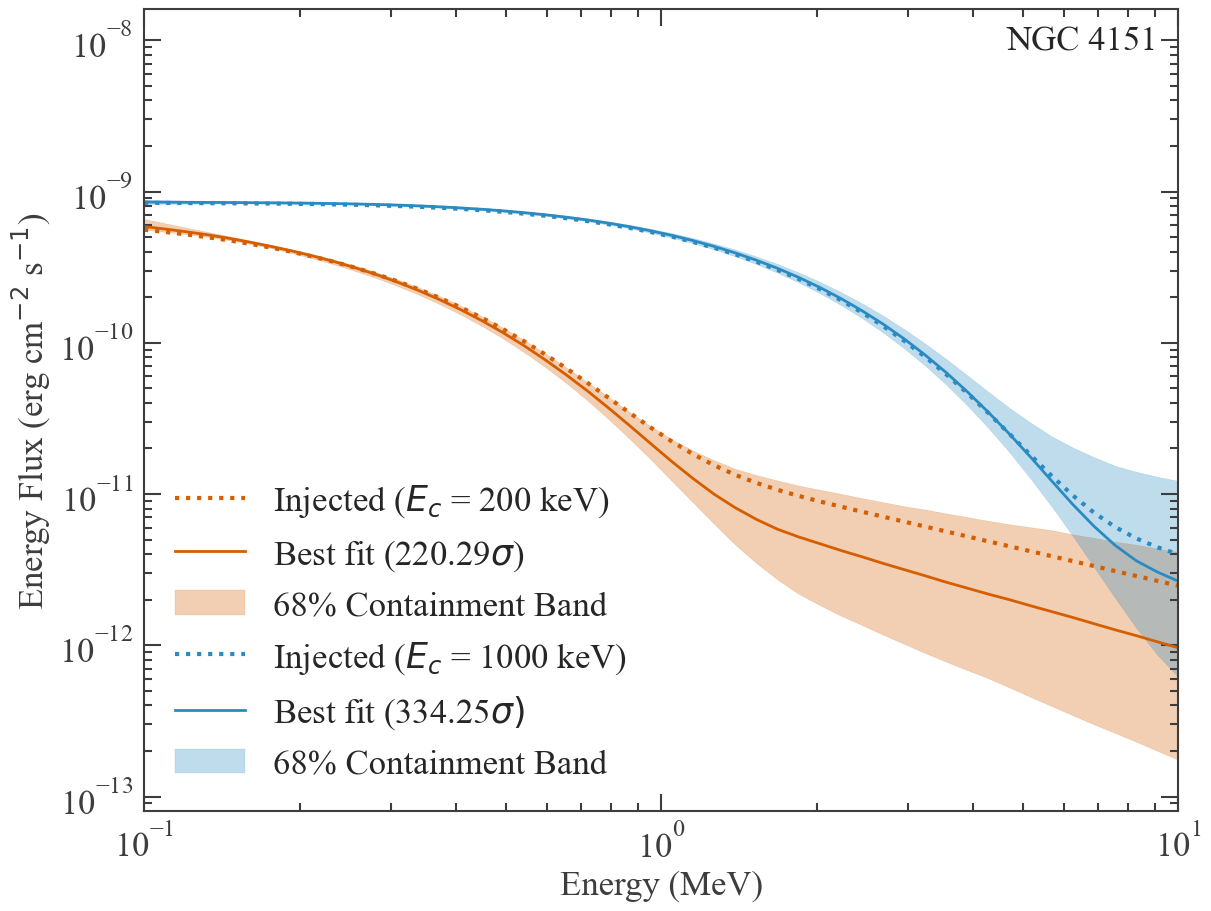

In [ ]:
FONT_SIZE = 25
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

Sigma = np.sqrt(TS)
Sigma_ec1000 = np.sqrt(TS_ec1000)

# # NGC 4151
text = f'NGC 4151'

# Plot individual components
# ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_median_thermal_200, label = "Cutoff PL", color = '#D55E00', ls='--', alpha=0.7)
# ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_median_tail_200, label = "Power Law", color = '#D55E00', ls='-.', alpha=0.7)
# Total component
ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_inj, color = '#D55E00', ls = ":", lw=3, label = "Injected ($E_c$ = 200 keV)")
ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_median, color = '#D55E00', label = f"Best fit ({Sigma:.2f}$\sigma$)")
ax.fill_between(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_lo, SED_KEV_TO_ERG * energy * energy *flux_hi, alpha = .3, color = '#D55E00', label = "68% Containment Band")

# Plot individual components
# ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_median_thermal_1000, label = "Cutoff PL", color = '#2A8BC3', ls='--', alpha=0.7)
# ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_median_tail_1000, label = "Power Law", color = '#2A8BC3', ls='-.', alpha=0.7)
# Total component
ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_inj_ec1000, color = '#2A8BC3', ls = ":", lw=3, label = "Injected ($E_c$ = 1000 keV)")
ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_median_ec1000, color = '#2A8BC3', label = f"Best fit ({Sigma_ec1000:.2f}$\sigma)$")
ax.fill_between(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_lo_ec1000, SED_KEV_TO_ERG * energy * energy *flux_hi_ec1000, alpha = .3, color='#2A8BC3', label = "68% Containment Band")

ax.text(
    0.98, 0.98,
    text,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
save_path = f"/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC4151_Cpl_Pl_Fit_200_1000_{exposure_4151}Months_FrozenIndex.pdf"

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylim(5e-5 * SED_KEV_TO_ERG, 10 * SED_KEV_TO_ERG)

ax.set_xlim((100) * KEV_TO_MEV, (10000) * KEV_TO_MEV)

# ax.xaxis.set_major_locator(mticker.FixedLocator([0.1, 5, 10]))
# ax.xaxis.set_major_formatter(
#     mticker.FixedFormatter(["0.1", "5", "10"])
# )

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (erg cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

# plt.savefig(save_path)

## Thermal SED (COSI-only)

This extracts a bin-by-bin SED from the thermal COSI-only fit. The photon index is frozen to the global-fit value in every bin. Because a single measured-energy band will not constrain the cutoff reliably, the helper below also fixes `xc` to the global-fit value. By default the COSI background nuisance parameter is left free, which matches the earlier working bin-by-bin behavior. You can optionally freeze it to a chosen reference value if you want a stricter one-parameter SED extraction. The helper also records whether a bin lands on the `K` lower bound, and if requested it can relax that lower bound and retry once before evaluating profile errors. You can also pass a stricter Minuit `ftol` to make the per-bin fits converge more tightly before MINOS is evaluated. If a manual fallback profile finds only an upper crossing, you can either keep that bin as an upper limit or convert it into a lower-bound-to-upper-crossing interval for plotting.


In [ ]:
from agn_cosi_fit_utils import (
    COSIPlugin,
    EnergyRangeCOSIPlugin,
    exact_background_only_statistic,
    make_cosi_background_parameter,
)
def _iter_model_sources(model):
    return [
        (name, child)
        for name, child in getattr(model, '_children', {}).items()
        if hasattr(child, 'spectrum')
    ]


def _find_shape_by_class(shape, shape_name):
    if shape is None:
        return None
    if shape.__class__.__name__ == shape_name:
        return shape

    for child_shape in getattr(shape, 'functions', []):
        match = _find_shape_by_class(child_shape, shape_name)
        if match is not None:
            return match

    return None


def _get_source_spectral_shape(source, shape_name='Cutoff_powerlaw'):
    main_component = source.spectrum.main

    for attr in (shape_name, 'shape', 'composite'):
        candidate = getattr(main_component, attr, None)
        match = _find_shape_by_class(candidate, shape_name)
        if match is not None:
            return match

    return None


def _resolve_source_name(model, source_name=None, shape_name='Cutoff_powerlaw'):
    sources = _iter_model_sources(model)

    if source_name is not None:
        source_names = [name for name, _ in sources]
        if source_name not in source_names:
            raise ValueError(f'Source {source_name!r} is not in optimized model. Available sources: {source_names}.')

        source = model[source_name]
        if _get_source_spectral_shape(source, shape_name=shape_name) is None:
            raise ValueError(f'Source {source_name!r} does not contain a {shape_name} shape.')

        return source_name

    source_names = [
        name
        for name, source in sources
        if _get_source_spectral_shape(source, shape_name=shape_name) is not None
    ]

    if len(source_names) != 1:
        raise ValueError(
            f'Expected one source with a {shape_name} shape, found {source_names}. '
            'Pass source_name to select the SED target explicitly.'
        )

    return source_names[0]


def _get_cutoff_powerlaw_shape(global_results, source_name=None):
    optimized_model = global_results.optimized_model
    source_name = _resolve_source_name(optimized_model, source_name=source_name)

    return _get_source_spectral_shape(optimized_model[source_name]), source_name


def build_thermal_sed_model(global_results, freeze_cutoff=True, source_name=None, freeze_non_target_parameters=True):
    from astromodels import clone_model

    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results, source_name=source_name)
    sed_model = clone_model(global_results.optimized_model)
    fit_shape = _get_source_spectral_shape(sed_model[source_name])

    if freeze_non_target_parameters:
        for parameter in sed_model.parameters.values():
            parameter.fix = True

    fit_shape.K.value = best_fit_shape.K.value
    fit_shape.K.min_value = max(best_fit_shape.K.value * 1e-3, 1e-12)
    fit_shape.K.max_value = best_fit_shape.K.value * 1e3
    fit_shape.K.fix = False
    fit_shape.index.value = best_fit_shape.index.value
    fit_shape.index.fix = True
    fit_shape.xc.value = best_fit_shape.xc.value
    fit_shape.xc.fix = freeze_cutoff

    return sed_model


def _hist_sum(hist):
    return float(_hist_values(hist).sum())


def _hist_values(hist):
    contents = hist.contents
    if hasattr(contents, 'compute'):
        contents = contents.compute()
    if hasattr(contents, 'todense'):
        contents = contents.todense()
    if hasattr(contents, 'value'):
        contents = contents.value
    return np.asarray(contents, dtype=float)


def _evaluate_model_photon_flux(model, energy):
    photon_flux = 0.0

    for _, source in _iter_model_sources(model):
        photon_flux += float(source.spectrum.main.shape.evaluate_at(energy))

    return photon_flux


def _with_target_k_value(model, source_name, k_value, evaluator):
    target_shape = _get_source_spectral_shape(model[source_name])
    k_parameter = target_shape.K
    original_k = float(k_parameter.value)
    original_min = k_parameter.min_value
    original_max = k_parameter.max_value
    requested_k = float(k_value)

    # Manual profiling can expand the live fit-model bound after the optimized
    # model snapshot was created. Temporarily expand the snapshot for evaluation.
    if original_min is not None and requested_k < float(original_min):
        k_parameter.min_value = requested_k
    if original_max is not None and requested_k > float(original_max):
        k_parameter.max_value = requested_k

    k_parameter.value = requested_k

    try:
        return evaluator()
    finally:
        k_parameter.value = original_k
        k_parameter.min_value = original_min
        k_parameter.max_value = original_max


def _integrate_model_energy_flux(model, source_name, k_value, e_min, e_max, n_points=256):
    energy_grid = np.geomspace(e_min, e_max, n_points)

    def evaluator():
        return np.asarray([_evaluate_model_photon_flux(model, energy) for energy in energy_grid])

    photon_flux = _with_target_k_value(model, source_name, k_value, evaluator)
    trapezoid = getattr(np, 'trapezoid', None)
    if trapezoid is None:
        trapezoid = np.trapz
    return float(trapezoid(energy_grid * photon_flux, energy_grid))


def _evaluate_model_sed_flux(model, source_name, k_value, energy):
    return _with_target_k_value(
        model,
        source_name,
        k_value,
        lambda: float(energy**2 * _evaluate_model_photon_flux(model, energy)),
    )


def _extract_profile_error(errors, suffix):
    if hasattr(errors, 'index'):
        for parameter_path in errors.index:
            if str(parameter_path).endswith(suffix):
                row = errors.loc[parameter_path]
                return float(row['negative_error']), float(row['positive_error'])
        return None

    for parameter_path, interval in errors.items():
        if str(parameter_path).endswith(suffix):
            return interval
    return None


def _get_global_background_rate(global_results):
    results_frame = global_results.get_data_frame()
    background_paths = [
        parameter_path
        for parameter_path in results_frame.index
        if 'background_' in str(parameter_path) or 'total_bkg' in str(parameter_path)
    ]

    if len(background_paths) != 1:
        raise ValueError(
            'Expected exactly one fitted background-rate parameter, '
            f'found {list(map(str, background_paths))}.'
        )

    return float(results_frame.loc[background_paths[0], 'value'])


def _run_joint_likelihood_fit(joint_likelihood):
    fit_status = 'covariance'
    try:
        joint_likelihood.fit(quiet=True)
    except Exception as exc:
        fit_status = f'no-covariance fallback ({type(exc).__name__})'
        joint_likelihood.fit(quiet=True, compute_covariance=False)
    return fit_status


def _get_joint_likelihood_statistic(joint_likelihood):
    statistic_frame = joint_likelihood.results.get_statistic_frame()

    if '-log(likelihood)' in statistic_frame.columns:
        statistic_column = statistic_frame['-log(likelihood)']
    else:
        numeric_frame = statistic_frame.select_dtypes(include=[np.number])
        if numeric_frame.empty:
            raise ValueError(f'No numeric statistic columns found in {list(statistic_frame.columns)}.')
        statistic_column = numeric_frame.iloc[:, 0]

    if 'total' in statistic_column.index:
        return float(statistic_column.loc['total'])

    return float(statistic_column.sum())


def _ts_to_sigma(ts_value):
    if not np.isfinite(ts_value) or ts_value <= 0:
        return 0.0

    return float(np.sqrt(ts_value))


def _make_minuit_with_ftol(minuit_ftol):
    if minuit_ftol is None:
        return None

    minuit = LocalMinimization('minuit')
    minuit.setup(ftol=float(minuit_ftol))

    return minuit


def _hits_lower_bound(value, lower_bound):
    if lower_bound is None or not np.isfinite(lower_bound):
        return False

    atol = max(1e-18, abs(float(lower_bound)) * 1e-6)
    return bool(np.isclose(float(value), float(lower_bound), rtol=1e-3, atol=atol))


def _interpolate_profile_crossing(x1, y1, x2, y2, target):
    if np.isclose(y1, y2):
        return float(0.5 * (x1 + x2))

    fraction = float((target - y1) / (y2 - y1))
    fraction = float(np.clip(fraction, 0.0, 1.0))

    if x1 > 0 and x2 > 0:
        return float(np.exp(np.log(x1) + fraction * (np.log(x2) - np.log(x1))))

    return float(x1 + fraction * (x2 - x1))


def _find_profile_crossing(x_values, delta_ts, threshold, side):
    if len(x_values) == 0:
        return None

    minimum_index = int(np.nanargmin(delta_ts))

    if side == 'left':
        for index in range(minimum_index - 1, -1, -1):
            y1 = float(delta_ts[index])
            y2 = float(delta_ts[index + 1])
            if np.isnan(y1) or np.isnan(y2):
                continue
            if np.isclose(y1, threshold):
                return float(x_values[index])
            if (y1 - threshold) * (y2 - threshold) <= 0:
                return _interpolate_profile_crossing(
                    float(x_values[index]),
                    y1,
                    float(x_values[index + 1]),
                    y2,
                    threshold,
                )
        return None

    for index in range(minimum_index, len(x_values) - 1):
        y1 = float(delta_ts[index])
        y2 = float(delta_ts[index + 1])
        if np.isnan(y1) or np.isnan(y2):
            continue
        if np.isclose(y2, threshold):
            return float(x_values[index + 1])
        if (y1 - threshold) * (y2 - threshold) <= 0:
            return _interpolate_profile_crossing(
                float(x_values[index]),
                y1,
                float(x_values[index + 1]),
                y2,
                threshold,
            )

    return None


def _manual_k_profile_interval(
    joint_likelihood,
    parameter_path,
    center_value,
    lower_bound,
    upper_bound,
    n_steps=61,
    target_delta_ts=1.0,
    max_expansions=12,
    scan_expand_factor=1e2,
):
    if center_value <= 0:
        raise ValueError('Manual K profiling requires a positive best-fit normalization.')

    tiny_positive = float(np.finfo(float).tiny)
    scan_min = max(float(lower_bound), tiny_positive)
    scan_max = float(upper_bound) if np.isfinite(upper_bound) else float(center_value) * 1e6

    if not np.isfinite(scan_max) or scan_max <= scan_min:
        raise ValueError('Invalid K scan bounds for manual profiling.')

    import matplotlib.pyplot as plt

    left_crossing = None
    right_crossing = None

    for _ in range(max_expansions + 1):
        x_values, _, profile_values, profile_figure = joint_likelihood.get_contours(
            parameter_path,
            param_1_minimum=float(scan_min),
            param_1_maximum=float(scan_max),
            param_1_n_steps=int(n_steps),
            progress=False,
            log=(True,),
        )
        plt.close(profile_figure)

        x_values = np.asarray(x_values, dtype=float)
        profile_values = np.asarray(profile_values, dtype=float)
        delta_ts = 2.0 * (profile_values - np.nanmin(profile_values))
        minimum_index = int(np.nanargmin(delta_ts))

        left_crossing = _find_profile_crossing(x_values, delta_ts, target_delta_ts, 'left')
        right_crossing = _find_profile_crossing(x_values, delta_ts, target_delta_ts, 'right')

        if left_crossing is not None and right_crossing is not None:
            status = f'manual K profile ok ({len(x_values)} points, {scan_min:.3e}-{scan_max:.3e})'
            return float(left_crossing), float(right_crossing), status

        expanded = False

        if left_crossing is None and minimum_index > 0 and delta_ts[0] < target_delta_ts and scan_min > lower_bound:
            new_scan_min = max(float(lower_bound), float(scan_min) / scan_expand_factor)
            if new_scan_min < scan_min:
                scan_min = new_scan_min
                expanded = True

        if right_crossing is None and minimum_index < (len(x_values) - 1) and delta_ts[-1] < target_delta_ts and scan_max < upper_bound:
            new_scan_max = min(float(upper_bound), float(scan_max) * scan_expand_factor)
            if new_scan_max > scan_max:
                scan_max = new_scan_max
                expanded = True

        if not expanded:
            break

    status = f'manual K profile incomplete ({len(x_values)} points, {scan_min:.3e}-{scan_max:.3e})'
    return left_crossing, right_crossing, status


def fit_thermal_cosi_sed(
    global_results,
    data_hist,
    bkg_hist,
    dr_path,
    sc_orientation,
    source_name=None,
    n_sed_bins=5,
    freeze_cutoff=True,
    freeze_non_target_parameters=True,
    freeze_background=False,
    background_rate_value=None,
    minuit_ftol=None,
    error_estimation='minos_then_manual',
    manual_k_profile_points=61,
    manual_one_sided_mode='upper_limit',
    relax_k_lower_bound=True,
    energy_min_keV=200,
    energy_max_keV=5000,
    scan_expand_factor=1e2,
    background_pseudocount=None,
):
    threeML_config.point_source.integrate_flux_method = 'trapz'

    em_edges = data_hist.axes['Em'].edges.to_value(u.keV)
    native_em_bins = np.flatnonzero(
        (em_edges[:-1] >= energy_min_keV) & (em_edges[1:] <= energy_max_keV)
    )

    if len(native_em_bins) == 0:
        raise ValueError(
            f'No native Em bins are fully contained in {energy_min_keV}-{energy_max_keV} keV.'
        )

    def _split_last_group_remainder(arr, n_groups):
        arr = np.asarray(arr)
        if len(arr) < n_groups:
            raise ValueError(f"Need at least {n_groups} native bins, got {len(arr)}.")

        sizes = [1] * (n_groups - 1)
        sizes.append(len(arr) - (n_groups - 1))

        groups = []
        start = 0
        for size in sizes:
            groups.append(arr[start:start + size])
            start += size

        return groups

    grouped_bins = _split_last_group_remainder(native_em_bins, n_sed_bins)

    sed_rows = []
    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results, source_name=source_name)
    frozen_index = best_fit_shape.index.value
    frozen_cutoff = best_fit_shape.xc.value
    global_k = float(best_fit_shape.K.value)
    global_background_rate = _get_global_background_rate(global_results)

    if background_rate_value is not None:
        background_rate_value = float(background_rate_value)

    for sed_bin_index, group in enumerate(grouped_bins, start=1):
        em_slice = slice(int(group[0]), int(group[-1]) + 1)
        e_min = float(em_edges[group[0]])
        e_max = float(em_edges[group[-1] + 1])
        e_ref = float(np.sqrt(e_min * e_max))
        data_counts = _hist_sum(data_hist.slice[{'Em': em_slice}])
        background_counts = _hist_sum(bkg_hist.slice[{'Em': em_slice}])
        data_slice_values = _hist_values(data_hist.slice[{'Em': em_slice}])
        raw_background_slice_values = _hist_values(bkg_hist.slice[{'Em': em_slice}])
        zero_background_mask = raw_background_slice_values == 0
        n_zero_background_cells = int(zero_background_mask.sum())
        data_counts_in_zero_background_cells = float(
            data_slice_values[zero_background_mask].sum()
        )

        dataset_name = f'cosi_sed_bin_{sed_bin_index}'

        bin_cosi = EnergyRangeCOSIPlugin(
            name=dataset_name,
            dr=dr_path,
            data=data_hist,
            bkg=bkg_hist,
            sc_orientation=sc_orientation,
            em_slice=em_slice,
            background_pseudocount=background_pseudocount,
            nuisance_param=make_cosi_background_parameter(dataset_name),
            earth_occ=True,
        )

        background_parameter = bin_cosi.nuisance_parameters[f'background_{dataset_name}']

        if freeze_background:
            if background_rate_value is None:
                background_parameter.value = global_background_rate
            else:
                background_parameter.value = background_rate_value
            background_parameter.fix = True
        else:
            background_parameter.fix = False
            if background_rate_value is not None:
                background_parameter.value = background_rate_value

        bin_model = build_thermal_sed_model(
            global_results,
            freeze_cutoff=freeze_cutoff,
            source_name=source_name,
            freeze_non_target_parameters=freeze_non_target_parameters,
        )
        bin_like = JointLikelihood(bin_model, DataList(bin_cosi), verbose=False)

        bin_minuit = _make_minuit_with_ftol(minuit_ftol)
        if bin_minuit is not None:
            bin_like.set_minimizer(bin_minuit)

        # threeML can reject every covariance sample in weak bins and then crash while building the summary table.
        fit_status = _run_joint_likelihood_fit(bin_like)

        bin_results = bin_like.results
        fit_shape = _get_source_spectral_shape(bin_results.optimized_model[source_name])
        k_value = float(fit_shape.K.value)
        k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
        k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
        k_lower_bound_relaxed = False

        if relax_k_lower_bound and _hits_lower_bound(k_value, k_min):
            relaxed_k_min = max(k_min * 1e-2, 1e-18)
            if relaxed_k_min < k_min:
                _get_source_spectral_shape(bin_model[source_name]).K.min_value = relaxed_k_min
                retry_status = _run_joint_likelihood_fit(bin_like)
                fit_status = f'{fit_status}; relaxed K min to {relaxed_k_min:.3e}; retry={retry_status}'
                bin_results = bin_like.results
                fit_shape = _get_source_spectral_shape(bin_results.optimized_model[source_name])
                k_value = float(fit_shape.K.value)
                k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
                k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
                k_lower_bound_relaxed = True

        k_parameter_path = fit_shape.K.path
        joint_statistic = _get_joint_likelihood_statistic(bin_like)

        null_result = exact_background_only_statistic(
            bin_cosi,
            profile_background=not freeze_background,
        )
        joint_null_statistic = null_result['statistic']
        null_background_rate = null_result['background_rate_hz']
        null_fit_status = (
            'exact background-only; background profiled analytically'
            if null_result['profiled_background']
            else 'exact background-only; background fixed'
        )
        ts_value_raw = 2.0 * (joint_null_statistic - joint_statistic)
        ts_value = max(0.0, float(ts_value_raw))
        sigma = _ts_to_sigma(ts_value)

        k_lo = k_value
        k_hi = k_value
        profile_error_status = 'not available'
        error_source = 'profile'
        has_two_sided_error = False

        run_manual_profile = error_estimation == 'manual_profile'

        if error_estimation in ('minos', 'minos_then_manual'):
            try:
                profile_errors = bin_like.get_errors(quiet=True)
                k_errors = _extract_profile_error(profile_errors, k_parameter_path)
                if k_errors is not None:
                    k_lo = max(k_value + float(k_errors[0]), k_min)
                    k_hi = min(k_value + float(k_errors[1]), k_max)
                    profile_error_status = 'ok'
                    error_source = 'profile'
                    has_two_sided_error = bool(np.isfinite(k_lo) and np.isfinite(k_hi) and (k_hi > k_lo))
                    if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                        run_manual_profile = True
                else:
                    profile_error_status = 'K profile error unavailable'
                    if error_estimation == 'minos_then_manual':
                        run_manual_profile = True
            except Exception as exc:
                profile_error_status = f'{type(exc).__name__}: {exc}'
                error_source = 'profile failed'

                if not _hits_lower_bound(k_value, k_min):
                    try:
                        covariance_errors = bin_results.get_data_frame(error_type='covariance')
                        k_cov_errors = _extract_profile_error(covariance_errors, k_parameter_path)
                        if k_cov_errors is not None:
                            cov_lo = max(k_value + float(k_cov_errors[0]), k_min)
                            cov_hi = min(k_value + float(k_cov_errors[1]), k_max)
                            if np.isfinite(cov_lo) and np.isfinite(cov_hi) and (cov_hi > cov_lo):
                                k_lo = cov_lo
                                k_hi = cov_hi
                                profile_error_status = f'covariance fallback ({type(exc).__name__})'
                                error_source = 'covariance fallback'
                                has_two_sided_error = True
                    except Exception:
                        pass

                if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                    run_manual_profile = True

        if run_manual_profile:
            profile_k_max = max(k_max, global_k * 1e6, k_value * 1e6)
            if np.isfinite(profile_k_max) and profile_k_max > k_max:
                profile_shape = _get_source_spectral_shape(bin_model[source_name])
                profile_shape.K.max_value = profile_k_max
                k_max = float(profile_shape.K.max_value)

            k_path = k_parameter_path
            try:
                profile_k_lo, profile_k_hi, manual_status = _manual_k_profile_interval(
                    bin_like,
                    k_path,
                    k_value,
                    k_min,
                    k_max,
                    n_steps=manual_k_profile_points,
                    max_expansions=12,
                    scan_expand_factor=scan_expand_factor,
                )

                if profile_k_lo is not None and profile_k_hi is not None and profile_k_hi > profile_k_lo:
                    k_lo = max(float(profile_k_lo), k_min)
                    k_hi = min(float(profile_k_hi), k_max)
                    profile_error_status = manual_status
                    error_source = 'manual profile'
                    has_two_sided_error = True
                elif profile_k_hi is not None:
                    k_hi = min(float(profile_k_hi), k_max)
                    if manual_one_sided_mode == 'lower_bound_interval':
                        k_lo = k_min
                        profile_error_status = manual_status.replace('incomplete', 'lower-bound interval')
                        error_source = 'manual lower-bound interval'
                        has_two_sided_error = True
                    else:
                        k_lo = k_value
                        profile_error_status = manual_status.replace('incomplete', 'upper limit')
                        error_source = 'manual upper limit'
                else:
                    profile_error_status = manual_status
                    error_source = 'manual profile incomplete'
            except Exception as exc:
                profile_error_status = f'manual K profile failed ({type(exc).__name__}: {exc})'
                error_source = 'manual profile failed'

        integrated_flux = _integrate_model_energy_flux(bin_results.optimized_model, source_name, k_value, e_min, e_max)
        integrated_flux_lo = _integrate_model_energy_flux(bin_results.optimized_model, source_name, k_lo, e_min, e_max)
        integrated_flux_hi = _integrate_model_energy_flux(bin_results.optimized_model, source_name, k_hi, e_min, e_max)
        sed_flux = _evaluate_model_sed_flux(bin_results.optimized_model, source_name, k_value, e_ref)
        sed_flux_lo = _evaluate_model_sed_flux(bin_results.optimized_model, source_name, k_lo, e_ref)
        sed_flux_hi = _evaluate_model_sed_flux(bin_results.optimized_model, source_name, k_hi, e_ref)
        background_rate = float(bin_cosi.nuisance_parameters[f'background_{dataset_name}'].value)
        background_is_fixed = bool(background_parameter.fix)
        hit_parameter_bound = bool(np.isclose(k_value, k_min) or (np.isfinite(k_max) and np.isclose(k_value, k_max)))
        is_upper_limit = bool(
            error_source == 'manual upper limit'
            or ((not has_two_sided_error) and _hits_lower_bound(k_value, k_min))
        )

        sed_rows.append(
            {
                'bin_index': sed_bin_index,
                'source_name': source_name,
                'e_min_keV': e_min,
                'e_max_keV': e_max,
                'e_ref_keV': e_ref,
                'bin_energy_flux_erg_cm2_s': integrated_flux,
                'bin_energy_flux_lo_erg_cm2_s': integrated_flux_lo,
                'bin_energy_flux_hi_erg_cm2_s': integrated_flux_hi,
                'sed_erg_cm2_s': sed_flux,
                'sed_lo_erg_cm2_s': sed_flux_lo,
                'sed_hi_erg_cm2_s': sed_flux_hi,
                'source_K': k_value,
                'source_K_lo': k_lo,
                'source_K_hi': k_hi,
                'source_K_over_global': k_value / global_k if global_k > 0 else np.nan,
                'background_rate_hz': background_rate,
                'background_rate_reference_hz': (
                    global_background_rate if background_rate_value is None else background_rate_value
                ),
                'background_requested_fixed': freeze_background,
                'background_rate_fixed': background_is_fixed,
                'background_released_for_retry': False,
                'data_counts': data_counts,
                'background_counts': background_counts,
                'background_pseudocount': background_pseudocount,
                'excess_counts': data_counts - background_counts,
                'n_zero_background_cells': n_zero_background_cells,
                'data_counts_in_zero_background_cells': data_counts_in_zero_background_cells,
                'joint_statistic': joint_statistic,
                'joint_null_statistic': joint_null_statistic,
                'null_source_mode': null_result['null_source_mode'],
                'null_background_rate_hz': null_background_rate,
                'ts_value_raw': ts_value_raw,
                'ts_value': ts_value,
                'sigma': sigma,
                'null_fit_status': null_fit_status,
                'fit_status': fit_status,
                'profile_error_status': profile_error_status,
                'error_source': error_source,
                'minuit_ftol': minuit_ftol,
                'error_estimation': error_estimation,
                'manual_one_sided_mode': manual_one_sided_mode,
                'k_lower_bound_relaxed': k_lower_bound_relaxed,
                'hit_parameter_bound': hit_parameter_bound,
                'is_upper_limit': is_upper_limit,
                'frozen_index': frozen_index,
                'frozen_cutoff_keV': frozen_cutoff,
            }
        )

    sed_df = pd.DataFrame(sed_rows)
    energy_flux_columns = [
        column for column in sed_df.columns
        if column.endswith("_erg_cm2_s")
    ]
    sed_df[energy_flux_columns] *= SED_KEV_TO_ERG
    return sed_df

In [ ]:
n_thermal_sed_bins = 10

# # Manual Scan
# thermal_cosi_sed_df = fit_thermal_cosi_sed(
#     global_results=results_sed,
#     data_hist=data_sed_hist,
#     bkg_hist=bkg_sed_hist,
#     dr_path=dr,
#     sc_orientation=sc_orientation,
#     n_sed_bins=n_thermal_sed_bins,
#     freeze_cutoff=True,
#     freeze_background=False,
#     minuit_ftol=1e-3,
#     error_estimation='manual_profile',
#     manual_k_profile_points=61,
#     energy_min_keV=200,
#     energy_max_keV=5000,
# )

thermal_cosi_sed_df = fit_thermal_cosi_sed(
    global_results=results_sed,
    data_hist=data_sed_hist,
    bkg_hist=bkg_sed_hist,
    dr_path=dr,
    sc_orientation=sc_orientation,
    n_sed_bins=n_thermal_sed_bins,
    freeze_cutoff=True,
    freeze_background=True,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=201,
    manual_one_sided_mode='lower_bound_interval',
    energy_min_keV=100,
    energy_max_keV=10000,
    scan_expand_factor=1e6,
    background_pseudocount=BACKGROUND_PSEUDOCOUNT,
)


display(
    thermal_cosi_sed_df[
        [
            "bin_index",
            "e_min_keV",
            "e_max_keV",
            "e_ref_keV",
            "bin_energy_flux_erg_cm2_s",
            "bin_energy_flux_lo_erg_cm2_s",
            "bin_energy_flux_hi_erg_cm2_s",
        ]
    ]
)

display(
    thermal_cosi_sed_df[
        [
            "bin_index",
            "source_K",
            "source_K_lo",
            "source_K_hi",
            "source_K_over_global",
            "background_rate_hz",
            "background_rate_reference_hz",
            "background_requested_fixed",
            "background_rate_fixed",
            "background_released_for_retry",
            "data_counts",
            "background_counts",
            "background_pseudocount",
            "excess_counts",
            "n_zero_background_cells",
            "data_counts_in_zero_background_cells",
            "joint_statistic",
            "joint_null_statistic",
            "null_source_mode",
            "null_background_rate_hz",
            "ts_value_raw",
            "ts_value",
            "sigma",
            "fit_status",
            "null_fit_status",
            "profile_error_status",
            "error_source",
            "minuit_ftol",
            "error_estimation",
            "k_lower_bound_relaxed",
            "hit_parameter_bound",
            "is_upper_limit",
        ]
    ]
)

14:13:28 INFO      set the minimizer to minuit                                             ]8;id=677902;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=509735;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=275434;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=670461;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

14:13:35 ERROR     Last status:                                                             ]8;id=256676;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=64474;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#161\161]8;;\

         ERROR     ┌─────────────────────────────────────────────────────────────────────── ]8;id=660372;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=17623;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#164\164]8;;\
                  ──┐                                                                                              

         ERROR     │                               External                                 ]8;id=440019;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=566522;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#164\164]8;;\
                  │                                                                                                

...

         INFO      set the minimizer to minuit                                             ]8;id=898701;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=22926;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

14:14:40 INFO      set the minimizer to minuit                                             ]8;id=834875;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=946469;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=406820;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=204105;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

,bin_index,e_min_keV,e_max_keV,e_ref_keV,bin_energy_flux_erg_cm2_s,bin_energy_flux_lo_erg_cm2_s,bin_energy_flux_hi_erg_cm2_s
0,1,100.000,158.489,125.892414,2.401945e-10,2.407198e-10,2.498106e-10
1,2,158.489,251.189,199.526172,1.817834e-10,1.773937e-10,1.861934e-10
2,3,251.189,398.107,316.227923,1.195425e-10,1.152953e-10,1.238202e-10
3,4,398.107,630.957,501.186989,5.027022e-11,4.480971e-11,5.573287e-11
4,5,630.957,1000.000,794.328018,1.994895e-11,1.185600e-11,2.804867e-11
5,6,1000.000,1584.890,1258.924144,6.175684e-15,6.166649e-15,1.099247e-11
6,7,1584.890,2511.890,1995.261723,3.513582e-15,3.376565e-15,6.085680e-12
7,8,2511.890,3981.070,3162.279229,1.012759e-11,3.094807e-12,2.331234e-11
8,9,3981.070,6309.570,5011.869895,1.781047e-15,1.678260e-15,3.483526e-12
9,10,6309.570,10000.000,7943.280179,1.422687e-15,1.193323e-15,8.420564e-12


,bin_index,source_K,source_K_lo,source_K_hi,source_K_over_global,background_rate_hz,background_rate_reference_hz,background_requested_fixed,background_rate_fixed,background_released_for_retry,data_counts,background_counts,background_pseudocount,excess_counts,n_zero_background_cells,data_counts_in_zero_background_cells,joint_statistic,joint_null_statistic,null_source_mode,null_background_rate_hz,ts_value_raw,ts_value,sigma,fit_status,null_fit_status,profile_error_status,error_source,minuit_ftol,error_estimation,k_lower_bound_relaxed,hit_parameter_bound,is_upper_limit
0,1,1.560342e-05,1.563754e-05,0.000016,1.000641,25.571928,25.571928,True,True,False,27106620.0,26969712.0,None,136908.0,4868,15.0,-1.806341e+08,-1.806230e+08,exact_zero,25.571928,22131.500071,22131.500071,148.766596,covariance,exact background-only; background fixed,"manual K profile ok (201 points, 1.559e-08-1.5...",manual profile,0.01,minos_then_manual,False,False,False
1,2,1.545743e-05,1.508416e-05,0.000016,0.991278,25.571928,25.571928,True,True,False,54505798.0,54265544.0,None,240254.0,3025,3.0,-3.936410e+08,-3.936380e+08,exact_zero,25.571928,5949.716851,5949.716851,77.134408,covariance,exact background-only; background fixed,ok,profile,0.01,minos_then_manual,False,False,False
2,3,1.612832e-05,1.555530e-05,0.000017,1.034302,25.571928,25.571928,True,True,False,41854694.0,41723608.0,None,131086.0,1764,11.0,-2.870008e+08,-2.869926e+08,exact_zero,25.571928,16273.289040,16273.289040,127.566802,covariance,exact background-only; background fixed,ok,profile,0.01,minos_then_manual,False,False,False
3,4,1.427633e-05,1.272559e-05,0.000016,0.915535,25.571928,25.571928,True,True,False,28361079.0,28320824.0,None,40255.0,1013,3.0,-1.804201e+08,-1.804180e+08,exact_zero,25.571928,4295.940291,4295.940291,65.543423,covariance,exact background-only; background fixed,ok,profile,0.01,minos_then_manual,False,False,False
4,5,1.658355e-05,9.855887e-06,0.000023,1.063496,25.571928,25.571928,True,True,False,18709609.0,18701936.0,None,7673.0,779,0.0,-1.110675e+08,-1.110675e+08,exact_zero,25.571928,6.079024,6.079024,2.465568,covariance,exact background-only; background fixed,ok,profile,0.01,minos_then_manual,False,False,False
5,6,1.561627e-08,1.559343e-08,0.000028,0.001001,25.571928,25.571928,True,True,False,14974115.0,14971952.0,None,2163.0,88,0.0,-8.567913e+07,-8.567913e+07,exact_zero,25.571928,-0.000201,0.000000,0.000000,covariance,exact background-only; background fixed,ok,profile,0.01,minos_then_manual,False,True,False
6,7,1.622619e-08,1.559343e-08,0.000028,0.001041,25.571928,25.571928,True,True,False,10141216.0,10142000.0,None,-784.0,197,0.0,-5.460766e+07,-5.460766e+07,exact_zero,25.571928,-0.000540,0.000000,0.000000,covariance,exact background-only; background fixed,ok,profile,0.01,minos_then_manual,False,True,False
7,8,6.689927e-05,2.044321e-05,0.000154,4.290222,25.571928,25.571928,True,True,False,4373379.0,4376160.0,None,-2781.0,931,1.0,-2.025952e+07,-2.025882e+07,exact_zero,25.571928,1402.503524,1402.503524,37.450014,covariance,exact background-only; background fixed,ok,profile,0.01,minos_then_manual,False,False,False
8,9,1.654846e-08,1.559343e-08,0.000032,0.001061,25.571928,25.571928,True,True,False,998956.0,999728.0,None,-772.0,5308,0.0,-3.460216e+06,-3.460216e+06,exact_zero,25.571928,-0.000511,0.000000,0.000000,covariance,exact background-only; background fixed,ok,profile,0.01,minos_then_manual,False,True,False
9,10,1.859058e-08,1.559343e-08,0.000110,0.001192,25.571928,25.571928,True,True,False,97008.0,96808.0,None,200.0,17384,0.0,-2.041888e+05,-2.041888e+05,exact_zero,25.571928,-0.000169,0.000000,0.000000,covariance,exact background-only; background fixed,ok,profile,0.01,minos_then_manual,False,True,False


In [ ]:
n_thermal_sed_bins = 10

# # Manual Scan
# thermal_cosi_sed_df_ec1000 = fit_thermal_cosi_sed(
#     global_results=results_sed_ec1000,
#     data_hist=data_sed_hist,
#     bkg_hist=bkg_sed_hist,
#     dr_path=dr,
#     sc_orientation=sc_orientation,
#     n_sed_bins=n_thermal_sed_bins,
#     freeze_cutoff=True,
#     freeze_background=False,
#     minuit_ftol=1e-3,
#     error_estimation='manual_profile',
#     manual_k_profile_points=61,
#     manual_one_sided_mode='lower_bound_interval',
#     energy_min_keV=200,
#     energy_max_keV=5000,
# )

thermal_cosi_sed_df_ec1000 = fit_thermal_cosi_sed(
    global_results=results_sed_ec1000,
    data_hist=data_sed_ec1000_hist,
    bkg_hist=bkg_sed_ec1000_hist,
    dr_path=dr,
    sc_orientation=sc_orientation,
    n_sed_bins=n_thermal_sed_bins,
    freeze_cutoff=True,
    freeze_background=True,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=81,
    manual_one_sided_mode='lower_bound_interval',
    energy_min_keV=100,
    energy_max_keV=10000,
    scan_expand_factor=1e3,
    background_pseudocount=BACKGROUND_PSEUDOCOUNT,
)

display(
    thermal_cosi_sed_df_ec1000[
        [
            "bin_index",
            "e_min_keV",
            "e_max_keV",
            "e_ref_keV",
            "bin_energy_flux_erg_cm2_s",
            "bin_energy_flux_lo_erg_cm2_s",
            "bin_energy_flux_hi_erg_cm2_s",
        ]
    ]
)

display(
    thermal_cosi_sed_df_ec1000[
        [
            "bin_index",
            "source_K",
            "source_K_lo",
            "source_K_hi",
            "source_K_over_global",
            "background_rate_hz",
            "background_rate_reference_hz",
            "background_requested_fixed",
            "background_rate_fixed",
            "background_released_for_retry",
            "data_counts",
            "background_counts",
            "background_pseudocount",
            "excess_counts",
            "n_zero_background_cells",
            "data_counts_in_zero_background_cells",
            "joint_statistic",
            "joint_null_statistic",
            "null_source_mode",
            "null_background_rate_hz",
            "ts_value_raw",
            "ts_value",
            "sigma",
            "fit_status",
            "null_fit_status",
            "profile_error_status",
            "error_source",
            "minuit_ftol",
            "error_estimation",
            "manual_one_sided_mode",
            "k_lower_bound_relaxed",
            "hit_parameter_bound",
            "is_upper_limit",
        ]
    ]
)

14:14:49 INFO      set the minimizer to minuit                                             ]8;id=122119;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=947953;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=387683;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=923972;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

14:14:58 INFO      set the minimizer to minuit                                             ]8;id=865412;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=532602;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=48358;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=949282;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

14:15:05 INFO      set the minimizer to minuit                                             ]8;id=245412;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=862367;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

         INFO      set the minimizer to minuit                                             ]8;id=825176;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=384339;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

14:15:28 INFO      set the minimizer to minuit                                             ]8;id=894807;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=308242;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=767827;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=164758;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

14:15:36 INFO      set the minimizer to minuit                                             ]8;id=786605;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=193914;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=54858;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=693552;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

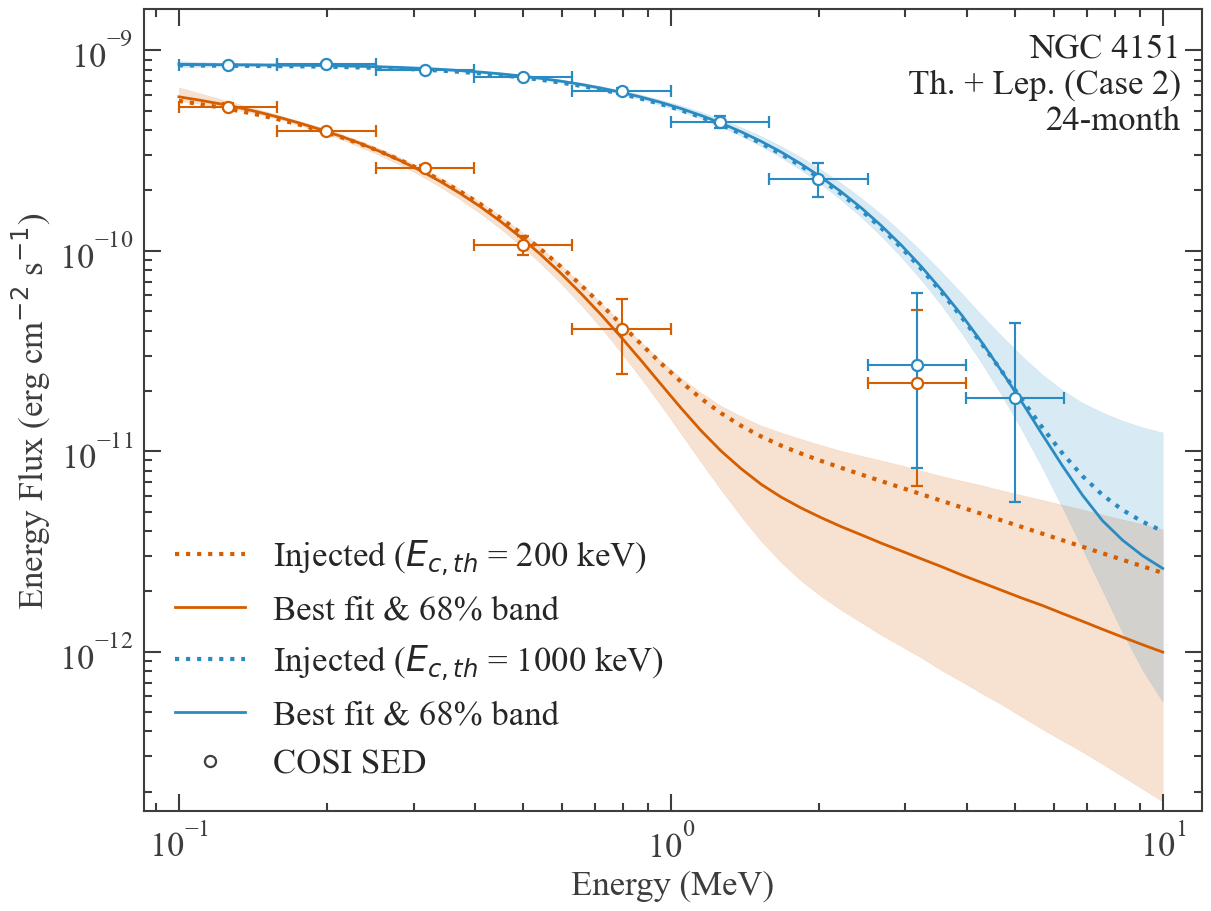

In [ ]:
FONT_SIZE = 25

plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update(
    {
        "font.weight": "550",
        "axes.titleweight": "550",
        "axes.labelweight": "550",
    }
)

def _make_xerr(df):
    return KEV_TO_MEV * np.vstack(
        [
            df["e_ref_keV"] - df["e_min_keV"],
            df["e_max_keV"] - df["e_ref_keV"],
        ]
    )

def _split_sed_detections(df, ts_threshold=4.0, min_plot_ts=1.0):
    plot_mask = np.ones(len(df), dtype=bool)
    upper_limit_mask = df['is_upper_limit'].copy()

    if 'ts_value' in df.columns:
        plot_mask = df['ts_value'] >= min_plot_ts
        upper_limit_mask = upper_limit_mask | (df['ts_value'] < ts_threshold)

    return (
        df.loc[plot_mask & ~upper_limit_mask].copy(),
        df.loc[plot_mask & upper_limit_mask].copy(),
    )

n_sed_bins_200 = len(thermal_cosi_sed_df)
n_sed_bins_1000 = len(thermal_cosi_sed_df_ec1000)

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

det_200, ul_200 = _split_sed_detections(thermal_cosi_sed_df)

det_1000, ul_1000 = _split_sed_detections(thermal_cosi_sed_df_ec1000)

ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_inj,
    color='#D55E00',
    ls=':',
    lw=3,
    label='Injected thermal model ($E_{c}$ = 200 keV)',
)
ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_median,
    color='#D55E00',
    lw=2,
    label='Global COSI-only fit ($E_{c}$ = 200 keV)',
)
ax.fill_between(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_lo,
    SED_KEV_TO_ERG * energy * energy * flux_hi,
    alpha=0.18,
    color='#D55E00',
)

ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_inj_ec1000,
    color='#2A8BC3',
    ls=':',
    lw=3,
    label='Injected thermal model ($E_{c}$ = 1000 keV)',
)
ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_median_ec1000,
    color='#2A8BC3',
    lw=2,
    label='Global COSI-only fit ($E_{c}$ = 1000 keV)',
)
ax.fill_between(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_lo_ec1000,
    SED_KEV_TO_ERG * energy * energy * flux_hi_ec1000,
    alpha=0.18,
    color='#2A8BC3',
)

if not det_200.empty:
    detection_xerr_200 = _make_xerr(det_200)
    detection_yerr_200 = np.vstack(
        [
            np.maximum(det_200['sed_erg_cm2_s'] - det_200['sed_lo_erg_cm2_s'], 0),
            np.maximum(det_200['sed_hi_erg_cm2_s'] - det_200['sed_erg_cm2_s'], 0),
        ]
    )

    ax.errorbar(
        det_200['e_ref_keV'] * KEV_TO_MEV,
        det_200['sed_erg_cm2_s'],
        xerr=detection_xerr_200,
        yerr=detection_yerr_200,
        fmt='o',
        color='#D55E00',
        ecolor='#D55E00',
        markerfacecolor='white',
        markeredgecolor='#D55E00',
        markeredgewidth=1.6,
        elinewidth=1.5,
        capsize=4,
        markersize=8,
        label=f'Bin-by-bin SED ($E_{{c}}$ = 200 keV; {len(det_200)} detections out of {n_sed_bins_200} bins)',
    )

if not ul_200.empty:
    upper_xerr_200 = _make_xerr(ul_200)
    upper_y_200 = ul_200['sed_hi_erg_cm2_s'].to_numpy()
    upper_yerr_200 = np.maximum(0.5 * upper_y_200, np.finfo(float).tiny)

    ax.errorbar(
        ul_200['e_ref_keV'] * KEV_TO_MEV,
        upper_y_200,
        xerr=upper_xerr_200,
        yerr=upper_yerr_200,
        uplims=True,
        fmt='v',
        color='#D55E00',
        ecolor='#D55E00',
        markerfacecolor='white',
        markeredgecolor='#D55E00',
        markeredgewidth=1.8,
        elinewidth=2.4,
        capsize=6,
        markersize=11,
        barsabove=True,
        zorder=6,
        label='_nolegend_',
    )

if not det_1000.empty:
    detection_xerr_1000 = _make_xerr(det_1000)
    detection_yerr_1000 = np.vstack(
        [
            np.maximum(det_1000['sed_erg_cm2_s'] - det_1000['sed_lo_erg_cm2_s'], 0),
            np.maximum(det_1000['sed_hi_erg_cm2_s'] - det_1000['sed_erg_cm2_s'], 0),
        ]
    )

    ax.errorbar(
        det_1000['e_ref_keV'] * KEV_TO_MEV,
        det_1000['sed_erg_cm2_s'],
        xerr=detection_xerr_1000,
        yerr=detection_yerr_1000,
        fmt='o',
        color='#2A8BC3',
        ecolor='#2A8BC3',
        markerfacecolor='white',
        markeredgecolor='#2A8BC3',
        markeredgewidth=1.6,
        elinewidth=1.5,
        capsize=4,
        markersize=8,
        label=f'Bin-by-bin SED ($E_{{c}}$ = 1000 keV; {len(det_1000)} detections out of {n_sed_bins_1000} bins)',
    )

if not ul_1000.empty:
    upper_xerr_1000 = _make_xerr(ul_1000)
    upper_y_1000 = ul_1000['sed_hi_erg_cm2_s'].to_numpy()
    upper_yerr_1000 = np.maximum(0.5 * upper_y_1000, np.finfo(float).tiny)

    ax.errorbar(
        ul_1000['e_ref_keV'] * KEV_TO_MEV,
        upper_y_1000,
        xerr=upper_xerr_1000,
        yerr=upper_yerr_1000,
        uplims=True,
        fmt='v',
        color='#2A8BC3',
        ecolor='#2A8BC3',
        markerfacecolor='white',
        markeredgecolor='#2A8BC3',
        markeredgewidth=1.8,
        elinewidth=2.4,
        capsize=6,
        markersize=11,
        barsabove=True,
        zorder=6,
        label='_nolegend_',
    )

legend_handles = [
    plt.Line2D([], [], color='#D55E00', ls=':', lw=3, label='Injected ($E_{c, th}$ = 200 keV)'),
    plt.Line2D([], [], color='#D55E00', lw=2, label='Best fit & 68% band'),
    plt.Line2D([], [], color='#2A8BC3', ls=':', lw=3, label='Injected ($E_{c, th}$ = 1000 keV)'),
    plt.Line2D([], [], color='#2A8BC3', lw=2, label='Best fit & 68% band'),
]

if not det_200.empty or not det_1000.empty:
    legend_handles.append(
        plt.Line2D([], [], color='0.25', marker='o', markerfacecolor='white', markeredgewidth=1.6, linestyle='None', markersize=8, label='COSI SED')
    )

ax.text(
    0.98, 0.97,
    f'NGC 4151\n Th. + Lep. (Case 2)\n{exposure_4151}-month',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylim(1e-4 * SED_KEV_TO_ERG, 1 * SED_KEV_TO_ERG)

ax.set_xlim((85) * KEV_TO_MEV, (12000) * KEV_TO_MEV)

# ax.xaxis.set_major_locator(mticker.FixedLocator([0.1, 5, 10]))
# ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.1", "5", "10"]))

ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)
ax.set_ylabel(r'Energy Flux (erg cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)
ax.legend(handles=legend_handles, fontsize=FONT_SIZE, loc='lower left', frameon=False)

save_path = f'/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC4151_Cpl_Pl_Fit_200_1000_{exposure_4151}Months_SED.pdf'
# plt.savefig(save_path)

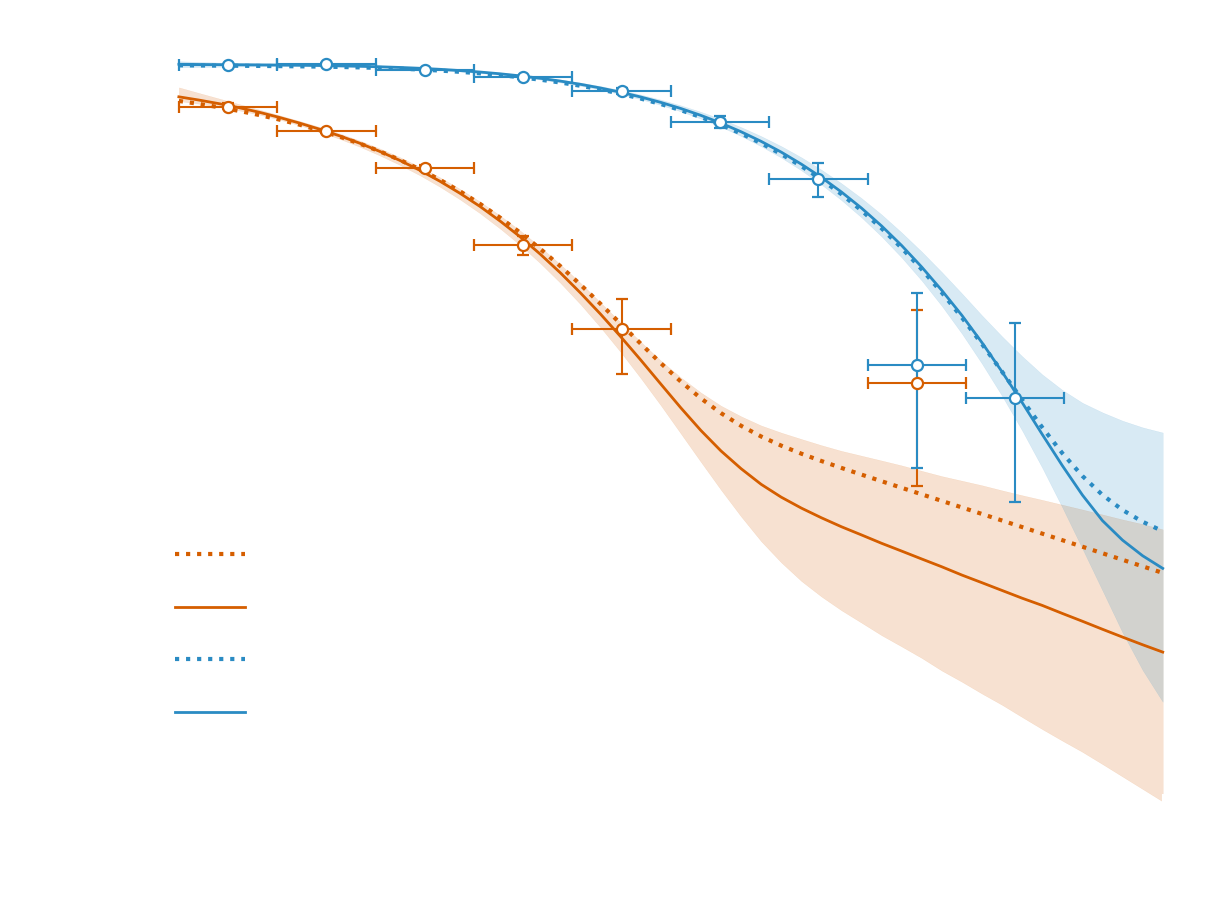

In [ ]:
# Transparent canvas with a white foreground for copying onto a dark background.
def _apply_transparent_dark_style(fig, axis):
    foreground_color = 'white'

    fig.patch.set_alpha(0)
    axis.patch.set_alpha(0)
    axis.tick_params(axis='both', which='both', colors=foreground_color)
    axis.xaxis.label.set_color(foreground_color)
    axis.yaxis.label.set_color(foreground_color)

    for spine in axis.spines.values():
        spine.set_color(foreground_color)

    for annotation in axis.texts:
        annotation.set_color(foreground_color)

    legend = axis.get_legend()
    if legend is not None:
        legend.get_frame().set_alpha(0)
        legend.get_frame().set_edgecolor(foreground_color)
        for legend_text in legend.get_texts():
            legend_text.set_color(foreground_color)
        for handle in getattr(legend, 'legend_handles', []):
            if handle.get_label() == 'COSI SED':
                handle.set_color(foreground_color)
                handle.set_markeredgecolor(foreground_color)
                handle.set_markerfacecolor('none')


_apply_transparent_dark_style(fig, ax)
display(fig)

## Case 2: 300-seed bin-by-bin SED ensemble

This section loads the 300 threshold seed IDs already stored by the Case 2 sensitivity runs for both cutoff energies. Only the representative HDF5 cube is stored, so each seed cube is regenerated deterministically with the same `default_rng(seed).poisson(source + background)` calculation. With the source shape and background fixed, each SED bin is a one-parameter Poisson template fit with an exact zero-source null. A 95% upper limit is profiled separately for every seed using $\Delta\mathrm{TS}=2.71$, and the plotted limit is the median of those 300 limits. Classification is bin-independent and uses the ensemble rather than the representative seed: median TS $=0$ is omitted; otherwise median TS $<4$ or a zero 16th-percentile recovered source scale is an upper limit; all remaining bins are detections. The representative HDF5 seed is checked against the regenerated ensemble counts, but it remains the input only to the full global fits above.

In [ ]:
from agn_sed_ensemble import (
    add_scaled_sed_columns,
    classify_sed_summary,
    load_threshold_seeds,
    run_sed_seed_ensemble,
)

CASE2_SED_ENSEMBLE_N_SEEDS = 300
CASE2_SED_ENSEMBLE_N_BINS = 10
CASE2_SED_ENSEMBLE_RECOMPUTE = False
CASE2_SED_ENSEMBLE_PSEUDOCOUNT = BACKGROUND_PSEUDOCOUNT
CASE2_SED_DETECTION_TS = 4.0

case2_ensemble_configuration = {
    'ec200': {
        'label': 'Case2_ec200',
        'manifest': ec200_manifest,
        'source_expectation': NGC4151_ec200,
        'injected_shape': spectrum_inj_ec200_total,
        'representative_sed': thermal_cosi_sed_df,
    },
    'ec1000': {
        'label': 'Case2_ec1000',
        'manifest': ec1000_manifest,
        'source_expectation': NGC4151_ec1000,
        'injected_shape': spectrum_inj_ec1000_total,
        'representative_sed': thermal_cosi_sed_df_ec1000,
    },
}

case2_sed_trials = {}
case2_sed_summary = {}
case2_representative_validation = {}
pseudocount_tag = (
    'tiny'
    if CASE2_SED_ENSEMBLE_PSEUDOCOUNT is None
    else f'{float(CASE2_SED_ENSEMBLE_PSEUDOCOUNT):.0e}'.replace('+', '')
)

for cutoff_label, configuration in case2_ensemble_configuration.items():
    manifest = configuration['manifest']
    norm_nt = float(manifest['grid_threshold_norm_nt'])
    seeds = load_threshold_seeds(
        manifest['trials_csv'],
        norm_nt,
        expected_count=CASE2_SED_ENSEMBLE_N_SEEDS,
    )
    output_dir = Path(manifest['trials_csv']).parent
    norm_tag = f'{norm_nt:.4g}'.replace('.', 'p')
    output_stem = (
        f"NGC4151_{cutoff_label}_Case2_SED_ensemble_{exposure_4151}months_"
        f"{len(seeds)}seeds_{CASE2_SED_ENSEMBLE_N_BINS}bins_"
        f"pseudocount_{pseudocount_tag}_normNT_{norm_tag}_null_exactZero_ul95"
    )
    trials_file = output_dir / f'{output_stem}_trials.csv'
    summary_file = output_dir / f'{output_stem}_summary.csv'

    if (
        not CASE2_SED_ENSEMBLE_RECOMPUTE
        and trials_file.exists()
        and summary_file.exists()
    ):
        seed_trials = pd.read_csv(trials_file)
        seed_summary = pd.read_csv(summary_file)
        print(f'Loaded {cutoff_label}: {trials_file}')
    else:
        seed_trials, seed_summary = run_sed_seed_ensemble(
            source_expectation=configuration['source_expectation'],
            background_expectation=bkg,
            seeds=seeds,
            n_sed_bins=CASE2_SED_ENSEMBLE_N_BINS,
            energy_min_keV=100,
            energy_max_keV=10000,
            background_pseudocount=CASE2_SED_ENSEMBLE_PSEUDOCOUNT,
            case_label=configuration['label'],
        )
        seed_trials.to_csv(trials_file, index=False)

        reference_energy = seed_summary['e_ref_keV'].to_numpy(dtype=float)
        injected_sed = SED_KEV_TO_ERG * reference_energy**2 * np.asarray(
            [configuration['injected_shape'].evaluate_at(e) for e in reference_energy],
            dtype=float,
        )
        seed_summary = add_scaled_sed_columns(seed_summary, injected_sed)

    required_summary_columns = {
        'source_scale_ul95_median', 'sed_ul95_median_erg_cm2_s',
        'ts_median', 'fraction_ts_ge_4', 'null_source_mode',
    }
    missing_summary_columns = required_summary_columns.difference(seed_summary.columns)
    if missing_summary_columns:
        raise ValueError(
            f'{cutoff_label} cached ensemble predates the exact-null/UL update: '
            f'{sorted(missing_summary_columns)}. Set CASE2_SED_ENSEMBLE_RECOMPUTE=True.'
        )

    seed_summary = classify_sed_summary(
        seed_summary, detection_ts=CASE2_SED_DETECTION_TS,
    )
    seed_summary['classification_seed_count'] = len(seeds)
    seed_summary.to_csv(summary_file, index=False)
    print(f'Saved {cutoff_label}: {summary_file}')

    representative_seed = int(manifest['representative_seed'])
    representative_trials = seed_trials.loc[
        seed_trials['seed'].astype(int) == representative_seed
    ].copy()
    if len(representative_trials) != CASE2_SED_ENSEMBLE_N_BINS:
        raise ValueError(
            f'{cutoff_label}: representative seed {representative_seed} has '
            f'{len(representative_trials)} ensemble bins, expected {CASE2_SED_ENSEMBLE_N_BINS}.'
        )
    representative_full = configuration['representative_sed'][
        ['bin_index', 'e_min_keV', 'e_max_keV', 'data_counts', 'ts_value']
    ].rename(columns={'ts_value': 'representative_full_ts'})
    representative_check = representative_full.merge(
        representative_trials[
            ['bin_index', 'e_min_keV', 'e_max_keV', 'data_counts', 'ts_value']
        ].rename(columns={
            'data_counts': 'ensemble_data_counts',
            'ts_value': 'representative_ensemble_ts',
        }),
        on=['bin_index', 'e_min_keV', 'e_max_keV'],
        how='inner',
    )
    if len(representative_check) != CASE2_SED_ENSEMBLE_N_BINS:
        raise ValueError(f'{cutoff_label}: representative and ensemble energy bins do not align.')
    if not np.allclose(
        representative_check['data_counts'],
        representative_check['ensemble_data_counts'],
        rtol=0.0, atol=0.0,
    ):
        raise ValueError(
            f'{cutoff_label}: the selected median file is not the Poisson realization '
            f'for representative seed {representative_seed}.'
        )
    representative_check['ts_difference_full_minus_ensemble'] = (
        representative_check['representative_full_ts']
        - representative_check['representative_ensemble_ts']
    )
    case2_representative_validation[cutoff_label] = representative_check

    case2_sed_trials[cutoff_label] = seed_trials
    case2_sed_summary[cutoff_label] = seed_summary

    display(
        seed_summary[
            [
                'bin_index', 'e_min_keV', 'e_max_keV',
                'source_scale_q16', 'source_scale_median', 'source_scale_q84',
                'source_scale_ul95_median',
                'ts_q16', 'ts_median', 'ts_q84', 'fraction_ts_zero',
                'fraction_ts_ge_4',
                'fraction_seeds_with_data_in_zero_background_cells',
                'null_source_mode', 'plot_role',
            ]
        ]
    )

Loaded ec200: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case2_ec200/NGC4151_ec200_Case2_SED_ensemble_24months_300seeds_10bins_pseudocount_tiny_null_exactZero_ul95_trials.csv
Saved ec200: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case2_ec200/NGC4151_ec200_Case2_SED_ensemble_24months_300seeds_10bins_pseudocount_tiny_null_exactZero_ul95_summary.csv


,bin_index,e_min_keV,e_max_keV,source_scale_q16,source_scale_median,source_scale_q84,source_scale_ul95_median,ts_q16,ts_median,ts_q84,fraction_ts_zero,fraction_ts_ge_4,fraction_seeds_with_data_in_zero_background_cells,null_source_mode,plot_role
0,1,100.000,158.489,0.970022,1.001548,1.032093,1.055228,16421.202570,20706.891481,26304.270029,0.000000,1.000000,1.000000,exact_zero,detection
1,2,158.489,251.189,0.978209,1.001005,1.023289,1.041442,4162.056226,5938.508941,8783.469737,0.000000,1.000000,0.960000,exact_zero,detection
2,3,251.189,398.107,0.966142,0.999672,1.037695,1.061155,6314.332272,9232.269322,13429.363058,0.000000,1.000000,0.996667,exact_zero,detection
3,4,398.107,630.957,0.900169,1.001860,1.091462,1.162852,1481.897904,2905.428605,4333.709799,0.000000,1.000000,0.860000,exact_zero,detection
4,5,630.957,1000.000,0.591450,0.963645,1.338985,1.598044,2.578678,8.781192,1415.544214,0.006667,0.720000,0.270000,exact_zero,detection
5,6,1000.000,1584.890,0.000000,0.981780,2.455335,3.817632,0.000000,0.324822,6.250169,0.316667,0.190000,0.156667,exact_zero,upper_limit
6,7,1584.890,2511.890,0.000000,0.000000,3.818914,6.909160,0.000000,0.000000,1.108510,0.643333,0.106667,0.106667,exact_zero,omitted
7,8,2511.890,3981.070,0.000000,0.000000,4.281479,7.607377,0.000000,0.000000,1401.118674,0.790000,0.210000,0.210000,exact_zero,omitted
8,9,3981.070,6309.570,0.000000,0.000000,3.653185,5.097220,0.000000,0.000000,1399.039340,0.736667,0.263333,0.263333,exact_zero,omitted
9,10,6309.570,10000.000,0.000000,0.000000,0.000000,16.568794,0.000000,0.000000,0.000000,0.913333,0.086667,0.086667,exact_zero,omitted


Loaded ec1000: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case2_ec1000/NGC4151_ec1000_Case2_SED_ensemble_24months_300seeds_10bins_pseudocount_tiny_null_exactZero_ul95_trials.csv
Saved ec1000: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case2_ec1000/NGC4151_ec1000_Case2_SED_ensemble_24months_300seeds_10bins_pseudocount_tiny_null_exactZero_ul95_summary.csv


,bin_index,e_min_keV,e_max_keV,source_scale_q16,source_scale_median,source_scale_q84,source_scale_ul95_median,ts_q16,ts_median,ts_q84,fraction_ts_zero,fraction_ts_ge_4,fraction_seeds_with_data_in_zero_background_cells,null_source_mode,plot_role
0,1,100.000,158.489,0.982751,0.998631,1.019183,1.029930,31057.954313,38097.574374,45079.518107,0.000000,1.000000,1.000000,exact_zero,detection
1,2,158.489,251.189,0.988981,1.000432,1.010799,1.018857,16606.206808,20596.271722,24084.764374,0.000000,1.000000,1.000000,exact_zero,detection
2,3,251.189,398.107,0.987864,0.999996,1.011058,1.018957,33396.999390,39879.963543,47062.391569,0.000000,1.000000,1.000000,exact_zero,detection
3,4,398.107,630.957,0.982378,0.999068,1.015225,1.026648,15025.780886,20486.058098,24783.253707,0.000000,1.000000,1.000000,exact_zero,detection
4,5,630.957,1000.000,0.971808,0.998377,1.024482,1.047860,5306.351769,8126.901923,11039.707398,0.000000,1.000000,0.993333,exact_zero,detection
5,6,1000.000,1584.890,0.930529,1.001795,1.082841,1.118813,3047.342713,5827.766504,8642.722052,0.000000,1.000000,0.990000,exact_zero,detection
6,7,1584.890,2511.890,0.788097,1.005705,1.184880,1.353239,1439.400123,4242.508199,7071.285276,0.000000,1.000000,0.956667,exact_zero,detection
7,8,2511.890,3981.070,0.397755,0.817324,1.460569,1.955475,1400.431937,2808.624978,5615.459412,0.086667,0.913333,0.913333,exact_zero,detection
8,9,3981.070,6309.570,0.000000,0.897758,1.853998,3.264149,0.000000,1398.359370,2802.213025,0.350000,0.650000,0.650000,exact_zero,upper_limit
9,10,6309.570,10000.000,0.000000,0.000000,5.934975,8.267686,0.000000,0.000000,1393.083800,0.830000,0.170000,0.170000,exact_zero,omitted


Saved ensemble SED plot: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC4151_Cpl_Pl_Fit_200_1000_24Months_SED_300SeedMedianTS.pdf


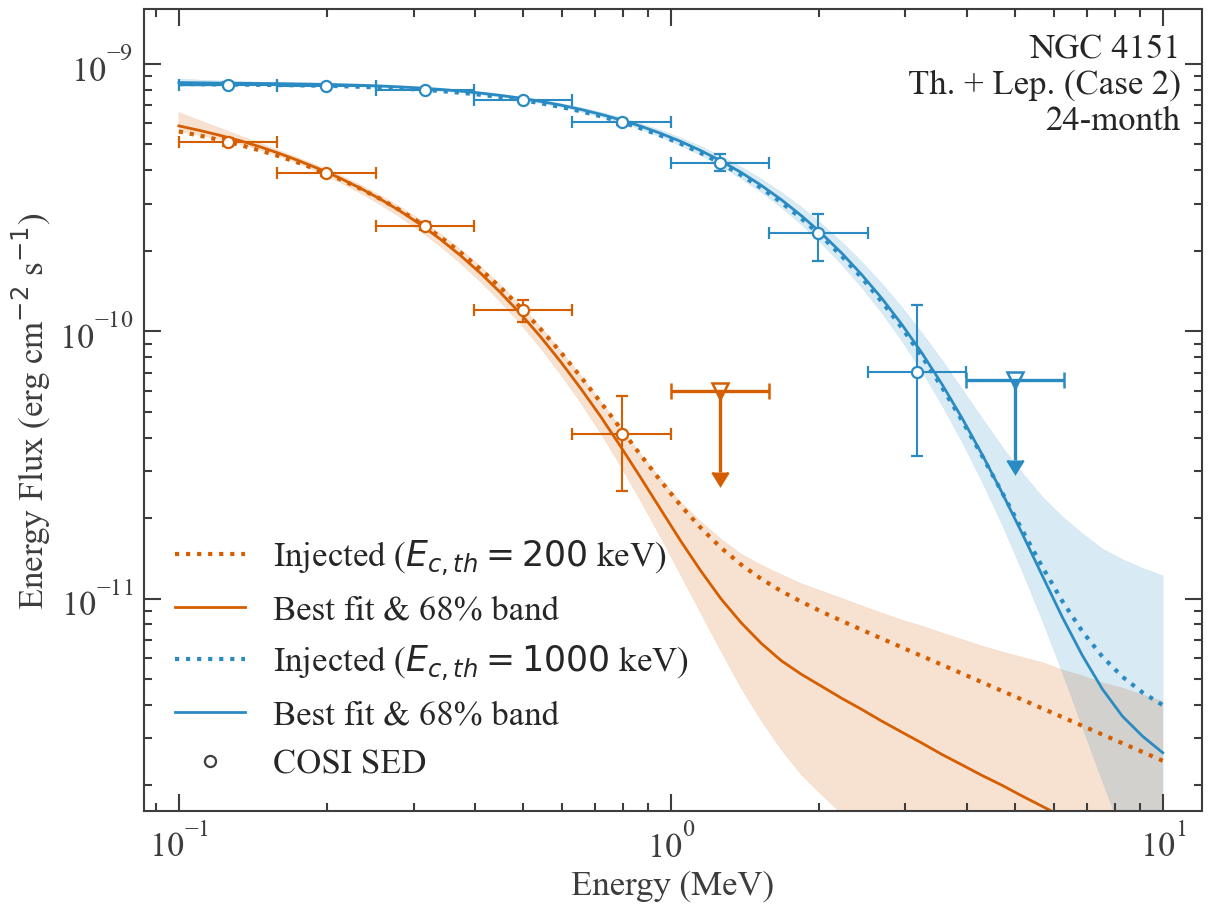

In [ ]:
FONT_SIZE = 25
plt.rcParams['agg.path.chunksize'] = 10000
plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550',
})

fig_ensemble, ax_ensemble = plt.subplots(figsize=(12, 9), constrained_layout=True)
ax_ensemble.xaxis.set_tick_params(
    which='major', size=12, width=1.5, direction='in',
    top=True, pad=8, labelsize=FONT_SIZE,
)
ax_ensemble.xaxis.set_tick_params(
    which='minor', size=6, width=1.5, direction='in', top=True, pad=8,
)
ax_ensemble.yaxis.set_tick_params(
    which='major', size=12, width=1.5, direction='in',
    right=True, pad=8, labelsize=FONT_SIZE,
)
ax_ensemble.yaxis.set_tick_params(
    which='minor', size=6, width=1.5, direction='in', right=True, pad=8,
)
ax_ensemble.spines['right'].set_visible(True)
ax_ensemble.spines['top'].set_visible(True)

# Match the original paper plot: smooth injected models, global fits,
# and their representative-seed 68% bands.
ax_ensemble.plot(
    energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy**2 * flux_inj,
    color='#D55E00', ls=':', lw=3,
)
ax_ensemble.plot(
    energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy**2 * flux_median,
    color='#D55E00', lw=2,
)
ax_ensemble.fill_between(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy**2 * flux_lo,
    SED_KEV_TO_ERG * energy**2 * flux_hi,
    alpha=0.18, color='#D55E00',
)
ax_ensemble.plot(
    energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy**2 * flux_inj_ec1000,
    color='#2A8BC3', ls=':', lw=3,
)
ax_ensemble.plot(
    energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy**2 * flux_median_ec1000,
    color='#2A8BC3', lw=2,
)
ax_ensemble.fill_between(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy**2 * flux_lo_ec1000,
    SED_KEV_TO_ERG * energy**2 * flux_hi_ec1000,
    alpha=0.18, color='#2A8BC3',
)

ensemble_plot_styles = {'ec200': '#D55E00', 'ec1000': '#2A8BC3'}

for cutoff_label, summary in case2_sed_summary.items():
    color = ensemble_plot_styles[cutoff_label]
    energy_mev = summary['e_ref_keV'].to_numpy(dtype=float) * KEV_TO_MEV
    energy_xerr = KEV_TO_MEV * np.vstack([
        summary['e_ref_keV'].to_numpy(dtype=float)
        - summary['e_min_keV'].to_numpy(dtype=float),
        summary['e_max_keV'].to_numpy(dtype=float)
        - summary['e_ref_keV'].to_numpy(dtype=float),
    ])
    sed_median = summary['sed_median_erg_cm2_s'].to_numpy(dtype=float)
    sed_q16 = summary['sed_q16_erg_cm2_s'].to_numpy(dtype=float)
    sed_q84 = summary['sed_q84_erg_cm2_s'].to_numpy(dtype=float)
    sed_ul95 = summary['sed_ul95_median_erg_cm2_s'].to_numpy(dtype=float)
    plot_role = summary['plot_role'].astype(str).to_numpy()
    detections = plot_role == 'detection'
    upper_limits = plot_role == 'upper_limit'

    ax_ensemble.errorbar(
        energy_mev[detections], sed_median[detections],
        xerr=energy_xerr[:, detections],
        yerr=np.vstack([
            np.maximum(0.0, sed_median[detections] - sed_q16[detections]),
            np.maximum(0.0, sed_q84[detections] - sed_median[detections]),
        ]),
        fmt='o', color=color, ecolor=color,
        markerfacecolor='white', markeredgecolor=color,
        markeredgewidth=1.6, elinewidth=1.5,
        capsize=4, markersize=8, zorder=5, label='_nolegend_',
    )
    ax_ensemble.errorbar(
        energy_mev[upper_limits], sed_ul95[upper_limits],
        xerr=energy_xerr[:, upper_limits],
        yerr=np.maximum(0.5 * sed_ul95[upper_limits], np.finfo(float).tiny),
        uplims=True, fmt='v', color=color, ecolor=color,
        markerfacecolor='white', markeredgecolor=color,
        markeredgewidth=1.8, elinewidth=2.4,
        capsize=6, markersize=11, barsabove=True, zorder=6,
        label='_nolegend_',
    )

legend_handles = [
    plt.Line2D([], [], color='#D55E00', ls=':', lw=3,
               label=r'Injected ($E_{c,th}=200$ keV)'),
    plt.Line2D([], [], color='#D55E00', lw=2,
               label='Best fit & 68% band'),
    plt.Line2D([], [], color='#2A8BC3', ls=':', lw=3,
               label=r'Injected ($E_{c,th}=1000$ keV)'),
    plt.Line2D([], [], color='#2A8BC3', lw=2,
               label='Best fit & 68% band'),
    plt.Line2D([], [], color='0.25', marker='o',
               markerfacecolor='white', markeredgewidth=1.6,
               linestyle='None', markersize=8, label='COSI SED'),
]

ax_ensemble.text(
    0.98, 0.97,
    f'NGC 4151\nTh. + Lep. (Case 2)\n{exposure_4151}-month',
    transform=ax_ensemble.transAxes, ha='right', va='top',
    fontsize=FONT_SIZE, fontweight='550',
)
ax_ensemble.set_xscale('log')
ax_ensemble.set_yscale('log')
ax_ensemble.set_xlim(85 * KEV_TO_MEV, 12000 * KEV_TO_MEV)
ax_ensemble.set_ylim(1e-3 * SED_KEV_TO_ERG, 1 * SED_KEV_TO_ERG)
ax_ensemble.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)
ax_ensemble.set_ylabel(
    r'Energy Flux (erg cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE,
)
ax_ensemble.legend(
    handles=legend_handles, fontsize=FONT_SIZE,
    loc='lower left', frameon=False,
)

ensemble_plot_path = Path(
    '/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/'
    'Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/'
    f'NGC4151_Cpl_Pl_Fit_200_1000_{exposure_4151}Months_'
    f'SED_{CASE2_SED_ENSEMBLE_N_SEEDS}SeedMedianTS.pdf'
)
ensemble_plot_path.parent.mkdir(parents=True, exist_ok=True)
fig_ensemble.savefig(ensemble_plot_path, bbox_inches='tight')
print(f'Saved ensemble SED plot: {ensemble_plot_path}')
plt.show()

In [ ]:
case2_sed_summary["ec200"][
    [
        "bin_index",
        "ts_median",
        "ts_q16",
        "ts_q84",
        "fraction_ts_zero",
        "fraction_ts_ge_4",
        "fraction_seeds_with_data_in_zero_background_cells",
        "source_scale_ul95_median",
        "plot_role",
    ]
]

,bin_index,ts_median,ts_q16,ts_q84,fraction_ts_zero,fraction_ts_ge_4,fraction_seeds_with_data_in_zero_background_cells
0,1,20706.891481,16421.202570,26304.270029,0.000000,1.000000,1.000000
1,2,5938.508941,4162.056226,8783.469737,0.000000,1.000000,0.960000
2,3,9232.269322,6314.332272,13429.363058,0.000000,1.000000,0.996667
3,4,2905.428605,1481.897904,4333.709799,0.000000,1.000000,0.860000
4,5,8.781192,2.578678,1415.544214,0.006667,0.720000,0.270000
5,6,0.324822,0.000000,6.250169,0.316667,0.190000,0.156667
6,7,0.000000,0.000000,1.108510,0.643333,0.106667,0.106667
7,8,0.000000,0.000000,1401.118674,0.790000,0.210000,0.210000
8,9,0.000000,0.000000,1399.039340,0.736667,0.263333,0.263333
9,10,0.000000,0.000000,0.000000,0.913333,0.086667,0.086667
